# Single-token DNA manifold diagnostics

Short tests for the Stage-1 one-token model: repeat-length control, motif generalisation, latent/string geometry, and interpolation.

In [67]:
from pathlib import Path
import sys, time, math, difflib
import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    from rapidfuzz import fuzz
except Exception:
    fuzz = None

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.dna_single_token_entropy_curriculum_autoencoder import build_model, sequence_to_tensor, tensor_to_sequence

CKPT = ROOT / 'checkpoints/dna_single_token_program_easy_len48_motif4/best.pt'
print('checkpoint:', CKPT)
print('exists:', CKPT.exists())

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('device:', device)

t0 = time.perf_counter()
checkpoint = torch.load(CKPT, map_location='cpu')
print(f'loaded checkpoint in {time.perf_counter() - t0:.2f}s')

class Args: pass
args = Args()
for k, v in checkpoint['args'].items():
    setattr(args, k, v)

model = build_model(args).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print('step:', checkpoint.get('step'), 'val_loss:', checkpoint.get('validation_loss'))
print('seq_len:', args.seq_len, 'latent_dim:', args.latent_dim, 'params:', sum(p.numel() for p in model.parameters()))

checkpoint: /Users/ogw/Documents/GitHub/Central_Dogma_AI/checkpoints/dna_single_token_program_easy_len48_motif4/best.pt
exists: True
device: mps
loaded checkpoint in 0.02s
step: 15000 val_loss: 0.05117964930832386
seq_len: 48 latent_dim: 32 params: 179782


In [68]:
BASE_COLORS = {'A':'#4caf50', 'C':'#2196f3', 'G':'#ff9800', 'T':'#e91e63'}

def ratio(a, b):
    if fuzz is not None:
        return fuzz.ratio(a, b) / 100.0
    return difflib.SequenceMatcher(None, a, b).ratio()

def batch_tensors(seqs):
    target = torch.zeros(len(seqs), args.seq_len, dtype=torch.long)
    mask = torch.zeros(len(seqs), args.seq_len, dtype=torch.float32)
    for i, seq in enumerate(seqs):
        seq = seq[:args.seq_len]
        target[i, :len(seq)] = sequence_to_tensor(seq)
        mask[i, :len(seq)] = 1
    return target.to(device), mask.to(device)

@torch.no_grad()
def encode_decode(seqs):
    target, mask = batch_tensors(seqs)
    out = model(target, mask)
    pred = out['soft_dna'].argmax(-1).detach().cpu()
    lengths = out['total_len'].detach().cpu().round().clamp(1, args.seq_len).long().tolist()
    decoded = [tensor_to_sequence(pred[i, :lengths[i]]) for i in range(len(seqs))]
    lat = out['latents'][:, 0, :].detach().cpu()
    usage = out['token_usage'][:, 0].detach().cpu()
    return {'decoded': decoded, 'latent': lat, 'usage': usage, 'lengths': lengths, 'raw': out}

@torch.no_grad()
def decode_latent(latent, usage=1.0):
    lat = torch.as_tensor(latent, dtype=torch.float32, device=device)[None, None, :]
    use = torch.tensor([[usage]], dtype=torch.float32, device=device)
    out = model.decode(lat, use, args.seq_len)
    pred = out['soft_dna'].argmax(-1)[0].detach().cpu()
    length = int(out['total_len'][0].detach().cpu().round().clamp(1, args.seq_len).item())
    return tensor_to_sequence(pred[:length]), length

def colour_seq(seq):
    from IPython.display import HTML
    spans = ''.join(f'<span style="background:{BASE_COLORS[b]};color:white;padding:1px 3px;margin:1px;font-family:monospace">{b}</span>' for b in seq)
    return HTML(f'<div style="line-height:1.8">{spans}</div>')

## 1. Repeat-length sweep

Does one latent/token scale motif repeat count into emitted length?

target: A | decoded: A | sim: 1.0
target: GT | decoded: GT | sim: 1.0
target: CGACGACGACGACGACGACGACGACGACGACGACGACGACGACGACGA | decoded: CGACGACGACGACGACGACGACGACGACGACGACGACAACGACACCA | sim: 0.947


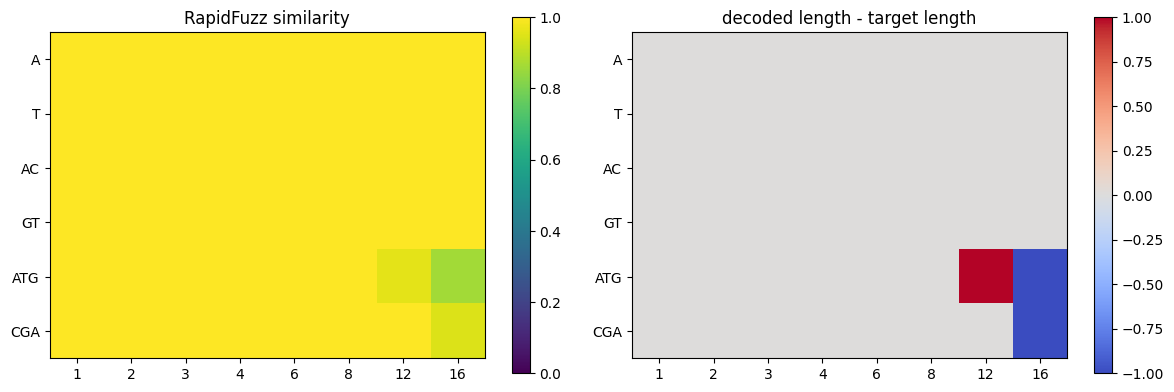

In [69]:
motifs = ['A', 'T', 'AC', 'GT', 'ATG', 'CGA']
repeats = [1, 2, 3, 4, 6, 8, 12, 16]
seqs = [(m * r)[:args.seq_len] for m in motifs for r in repeats]
labels = [(m, r, len((m * r)[:args.seq_len])) for m in motifs for r in repeats]
res = encode_decode(seqs)

sim = np.array([ratio(a, b) for a, b in zip(seqs, res['decoded'])]).reshape(len(motifs), len(repeats))
out_len = np.array(res['lengths']).reshape(len(motifs), len(repeats))
target_len = np.array([x[2] for x in labels]).reshape(len(motifs), len(repeats))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(sim, vmin=0, vmax=1, cmap='viridis')
axes[0].set_title('RapidFuzz similarity')
axes[0].set_xticks(range(len(repeats)), repeats)
axes[0].set_yticks(range(len(motifs)), motifs)
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(out_len - target_len, cmap='coolwarm')
axes[1].set_title('decoded length - target length')
axes[1].set_xticks(range(len(repeats)), repeats)
axes[1].set_yticks(range(len(motifs)), motifs)
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()

for idx in [0, len(seqs)//2, len(seqs)-1]:
    print('target:', seqs[idx], '| decoded:', res['decoded'][idx], '| sim:', round(ratio(seqs[idx], res['decoded'][idx]), 3))

## 2. Latent geometry

Do string-similar sequences become latent-similar sequences?

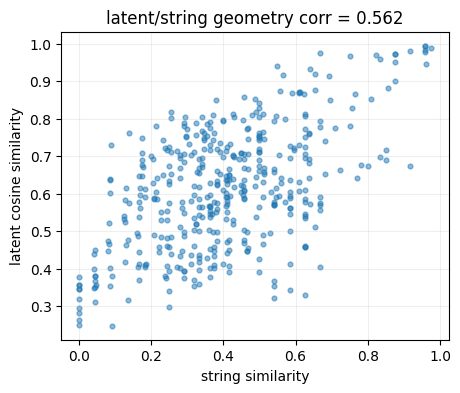

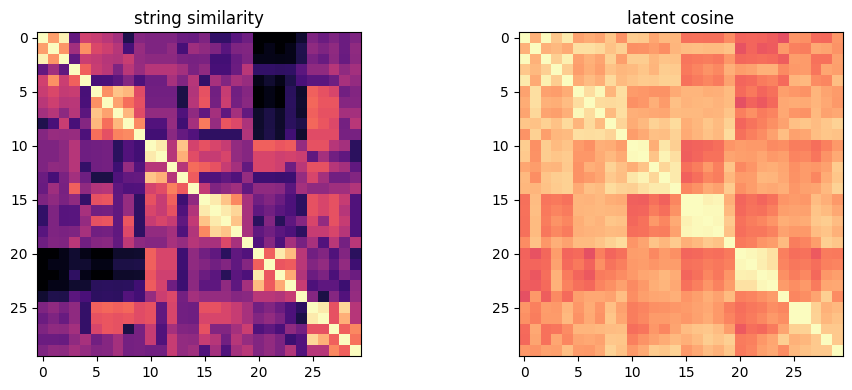

In [70]:
rng = np.random.default_rng(3)
base_seqs = ['A' * 20, 'AC' * 12, 'ATG' * 8, 'CGA' * 8, 'GT' * 12, 'TAC' * 8]

def mutate(seq, n=2):
    bases = np.array(list(seq))
    for _ in range(n):
        if rng.random() < 0.7 and len(bases) > 0:
            i = rng.integers(0, len(bases))
            choices = [b for b in 'ACGT' if b != bases[i]]
            bases[i] = rng.choice(choices)
        elif rng.random() < 0.5 and len(bases) > 1:
            bases = np.delete(bases, rng.integers(0, len(bases)))
        elif len(bases) < args.seq_len:
            bases = np.insert(bases, rng.integers(0, len(bases)+1), rng.choice(list('ACGT')))
    return ''.join(bases.tolist())[:args.seq_len]

seqs = []
for s in base_seqs:
    seqs.append(s[:args.seq_len])
    for edits in [1, 2, 4, 6]:
        seqs.append(mutate(s[:args.seq_len], edits))

res = encode_decode(seqs)
z = torch.nn.functional.normalize(res['latent'], dim=-1).numpy()
latent_sim = z @ z.T
string_sim = np.array([[ratio(a, b) for b in seqs] for a in seqs])
tri = np.triu_indices(len(seqs), k=1)
corr = np.corrcoef(string_sim[tri], latent_sim[tri])[0, 1]

plt.figure(figsize=(5, 4))
plt.scatter(string_sim[tri], latent_sim[tri], s=12, alpha=0.5)
plt.xlabel('string similarity')
plt.ylabel('latent cosine similarity')
plt.title(f'latent/string geometry corr = {corr:.3f}')
plt.grid(alpha=0.2)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(string_sim, vmin=0, vmax=1, cmap='magma'); axes[0].set_title('string similarity')
axes[1].imshow(latent_sim, vmin=-1, vmax=1, cmap='magma'); axes[1].set_title('latent cosine')
plt.tight_layout()

## 2b. Structured repeat-unit geometry

Homopolymers, di-, tri-, and 4-mer motifs across repeat counts. This is a cleaner test of whether repeat count and motif identity organise smoothly in latent space.

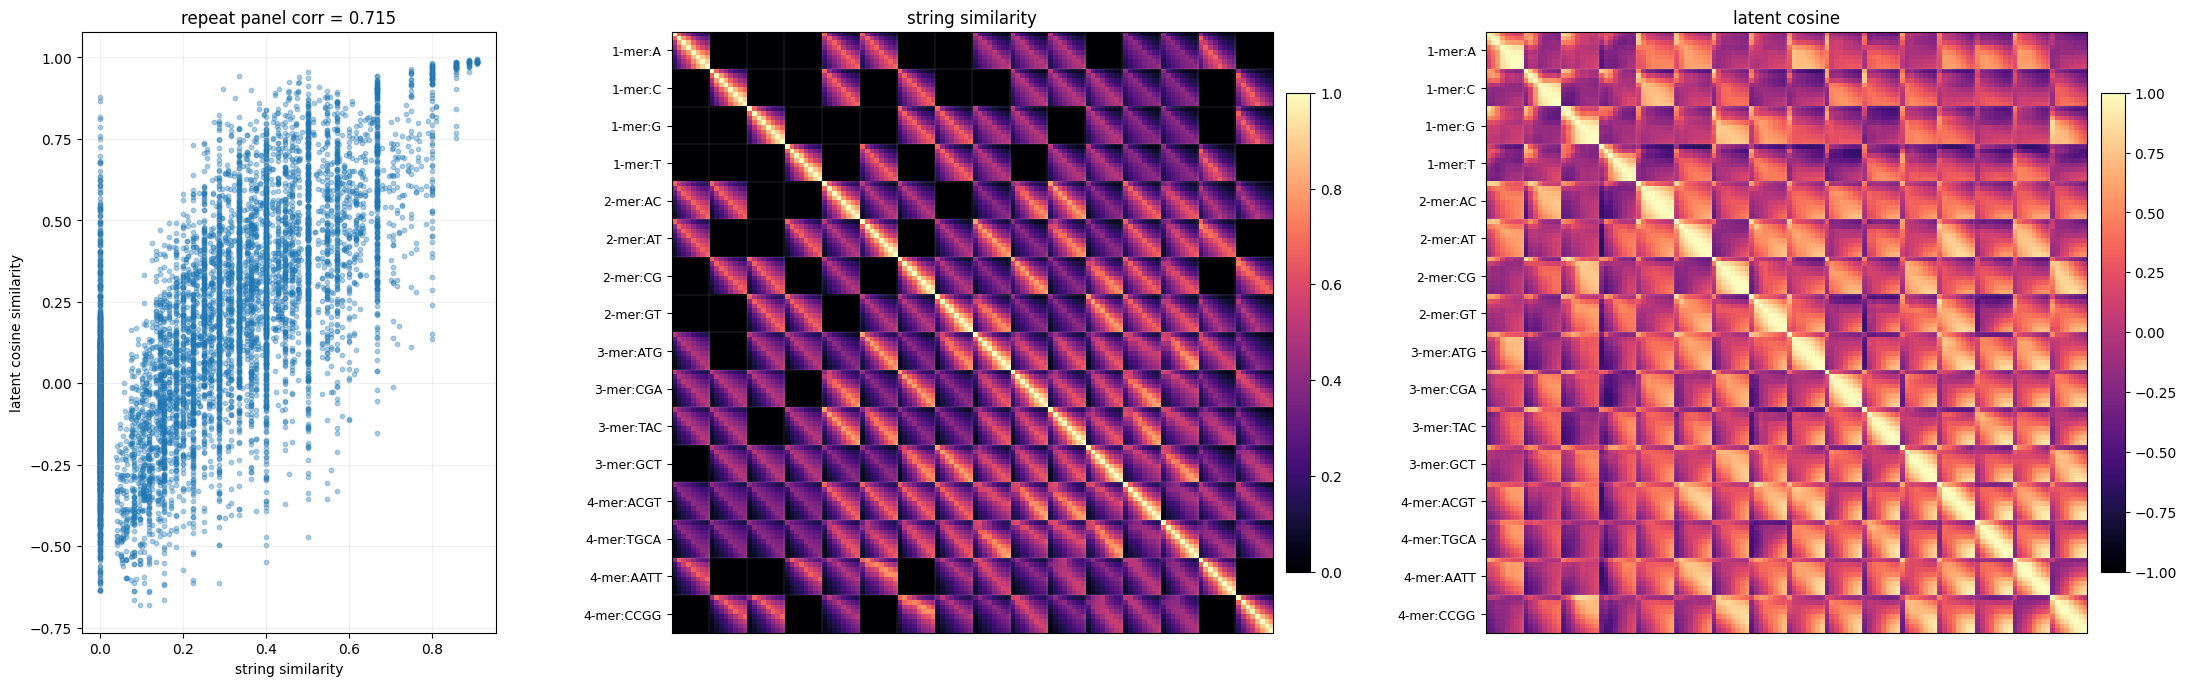

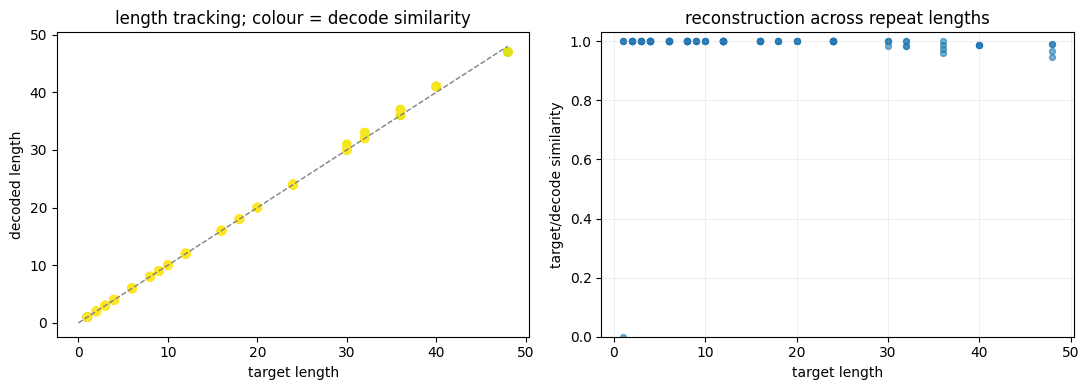

('1-mer', 'A', 1, 1) target: A | decoded: A | sim: 1.0
('1-mer', 'A', 12, 12) target: AAAAAAAAAAAA | decoded: AAAAAAAAAAAA | sim: 1.0
('3-mer', 'ATG', 1, 3) target: ATG | decoded: ATG | sim: 1.0
('4-mer', 'CCGG', 12, 48) target: CCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGG | decoded: CCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCCGGCTGGCCC | sim: 0.947


In [71]:
repeat_motifs = {
    '1-mer': ['A', 'C', 'G', 'T'],
    '2-mer': ['AC', 'AT', 'CG', 'GT'],
    '3-mer': ['ATG', 'CGA', 'TAC', 'GCT'],
    '4-mer': ['ACGT', 'TGCA', 'AATT', 'CCGG'],
}
repeat_counts = [1, 2, 3, 4, 6, 8, 10, 12]

seqs, labels, y_ticks = [], [], []
for group, motifs in repeat_motifs.items():
    for motif in motifs:
        y_ticks.append(f'{group}:{motif}')
        for count in repeat_counts:
            seq = (motif * count)[:args.seq_len]
            seqs.append(seq)
            labels.append((group, motif, count, len(seq)))

res = encode_decode(seqs)
z = torch.nn.functional.normalize(res['latent'], dim=-1).numpy()
latent_sim = z @ z.T
string_sim = np.array([[ratio(a, b) for b in seqs] for a in seqs])
tri = np.triu_indices(len(seqs), k=1)
corr = np.corrcoef(string_sim[tri], latent_sim[tri])[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(22, 7), gridspec_kw={'width_ratios': [1.0, 1.65, 1.65]})
axes[0].scatter(string_sim[tri], latent_sim[tri], s=10, alpha=0.35)
axes[0].set_xlabel('string similarity')
axes[0].set_ylabel('latent cosine similarity')
axes[0].set_title(f'repeat panel corr = {corr:.3f}')
axes[0].grid(alpha=0.2)

im1 = axes[1].imshow(string_sim, vmin=0, vmax=1, cmap='magma')
axes[1].set_title('string similarity')
fig.colorbar(im1, ax=axes[1], fraction=0.035, pad=0.02)

im2 = axes[2].imshow(latent_sim, vmin=-1, vmax=1, cmap='magma')
axes[2].set_title('latent cosine')
fig.colorbar(im2, ax=axes[2], fraction=0.035, pad=0.02)

block = len(repeat_counts)
for ax in axes[1:]:
    for boundary in range(block, len(seqs), block):
        ax.axhline(boundary - 0.5, color='white', lw=0.25, alpha=0.4)
        ax.axvline(boundary - 0.5, color='white', lw=0.25, alpha=0.4)
    ax.set_xticks([])
    ax.set_yticks([i * block + block/2 - 0.5 for i in range(len(y_ticks))], y_ticks, fontsize=9)
    ax.set_aspect('equal')
plt.tight_layout(pad=1.2)
plt.show()

# Per motif: does decoded length track repeat-derived target length?
target_lengths = np.array([x[3] for x in labels])
decoded_lengths = np.array(res['lengths'])
seq_ratio = np.array([ratio(a, b) for a, b in zip(seqs, res['decoded'])])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(target_lengths, decoded_lengths, c=seq_ratio, cmap='viridis', vmin=0, vmax=1)
axes[0].plot([0, args.seq_len], [0, args.seq_len], '--', color='gray', lw=1)
axes[0].set_xlabel('target length')
axes[0].set_ylabel('decoded length')
axes[0].set_title('length tracking; colour = decode similarity')

axes[1].scatter(target_lengths, seq_ratio, s=18, alpha=0.6)
axes[1].set_xlabel('target length')
axes[1].set_ylabel('target/decode similarity')
axes[1].set_ylim(0, 1.03)
axes[1].set_title('reconstruction across repeat lengths')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

for idx in [0, block-1, len(seqs)//2, len(seqs)-1]:
    print(labels[idx], 'target:', seqs[idx], '| decoded:', res['decoded'][idx], '| sim:', round(seq_ratio[idx], 3))


## 3. Latent interpolation

Interpolate between two encoded sequences and decode each point.

In [72]:
start = 'AC' * 10
end = 'GTG' * 8
enc = encode_decode([start, end])
z0, z1 = enc['latent'][0], enc['latent'][1]
u0, u1 = float(enc['usage'][0]), float(enc['usage'][1])

print('start target :', start)
print('start decode :', enc['decoded'][0])
print('end target   :', end)
print('end decode   :', enc['decoded'][1])
print()

for alpha in np.linspace(0, 1, 9):
    z = (1-alpha) * z0 + alpha * z1
    usage = (1-alpha) * u0 + alpha * u1
    decoded, length = decode_latent(z, usage=usage)
    print(f'a={alpha:.2f} len={length:02d} sim_start={ratio(start, decoded):.2f} sim_end={ratio(end, decoded):.2f}  {decoded}')

start target : ACACACACACACACACACAC
start decode : ACACACACACACACACACAC
end target   : GTGGTGGTGGTGGTGGTGGTGGTG
end decode   : GTGGTGGTGGTGGTGGTGGTGGTG

a=0.00 len=20 sim_start=1.00 sim_end=0.00  ACACACACACACACACACAC
a=0.12 len=20 sim_start=1.00 sim_end=0.00  ACACACACACACACACACAC
a=0.25 len=21 sim_start=0.88 sim_end=0.04  ACGCACACACACACACCCACA
a=0.38 len=22 sim_start=0.81 sim_end=0.09  ACGTCCACACACACACCCACAC
a=0.50 len=22 sim_start=0.52 sim_end=0.13  ACGTCCACGCCCACACCCACAC
a=0.62 len=23 sim_start=0.28 sim_end=0.30  ATGTGGGCGGCCGTGCTGGTGGC
a=0.75 len=23 sim_start=0.09 sim_end=0.60  GTCGGGGTGGCGGTGGTGGTGGT
a=0.88 len=24 sim_start=0.00 sim_end=1.00  GTGGTGGTGGTGGTGGTGGTGGTG
a=1.00 len=24 sim_start=0.00 sim_end=1.00  GTGGTGGTGGTGGTGGTGGTGGTG


## 3b. Repeat-count interpolation

Encode the same motif at a low and high repeat count, interpolate between the two latents, then check whether decoded length/repeat count changes smoothly.

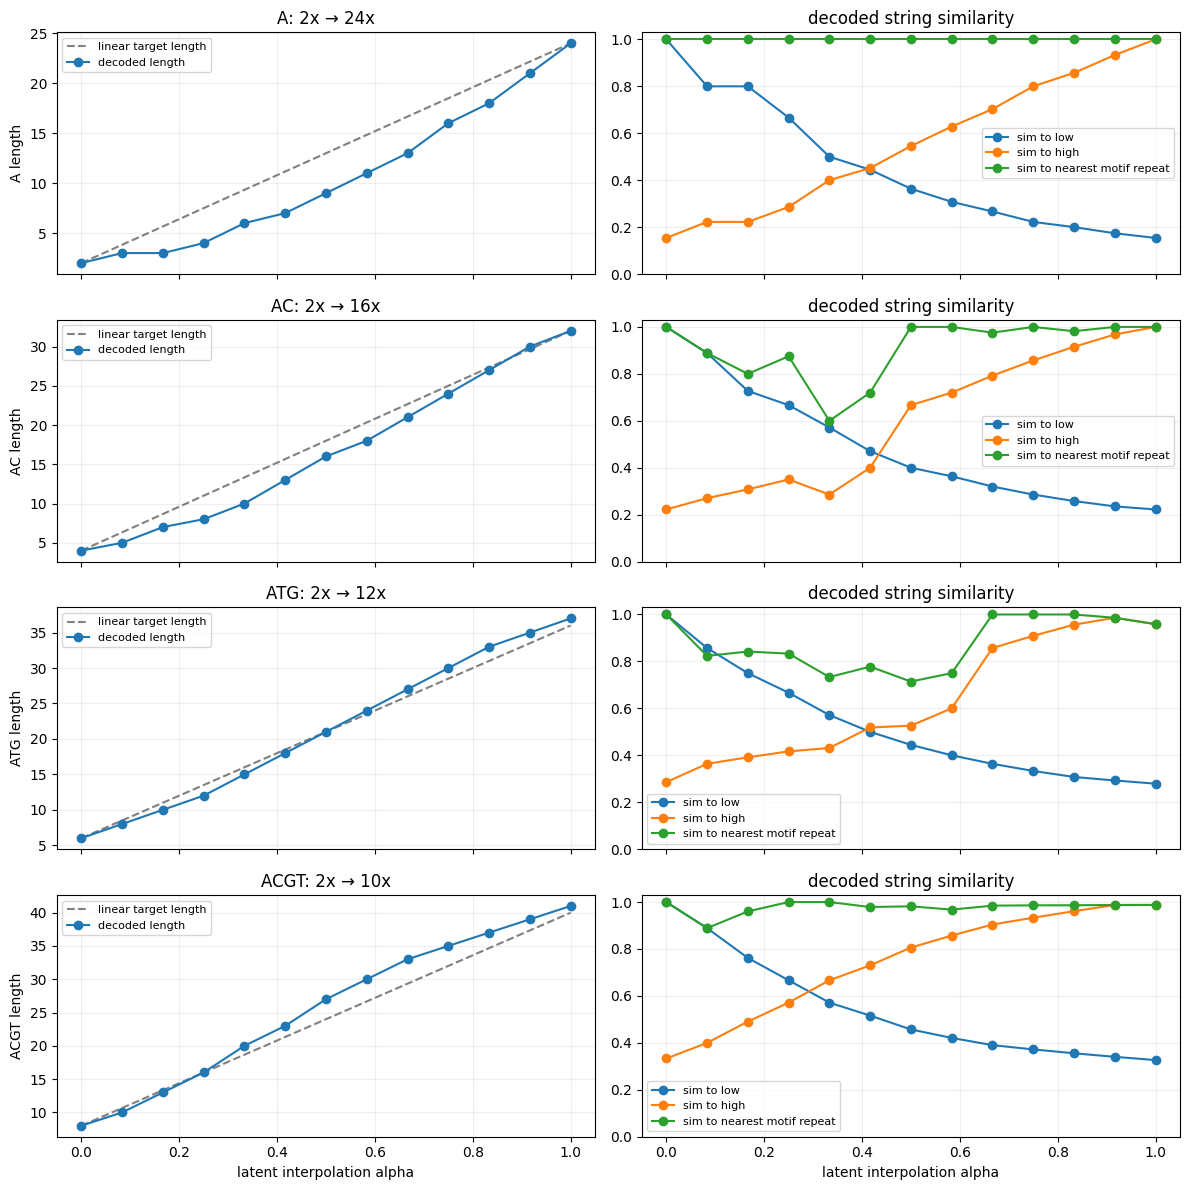


A interpolation
a=0.00 len=02 reps~2.0 motif_sim=1.00  AA
a=0.25 len=04 reps~4.0 motif_sim=1.00  AAAA
a=0.50 len=09 reps~9.0 motif_sim=1.00  AAAAAAAAA
a=0.75 len=16 reps~16.0 motif_sim=1.00  AAAAAAAAAAAAAAAA
a=1.00 len=24 reps~24.0 motif_sim=1.00  AAAAAAAAAAAAAAAAAAAAAAAA

AC interpolation
a=0.00 len=04 reps~2.0 motif_sim=1.00  ACAC
a=0.25 len=08 reps~4.0 motif_sim=0.88  ACACCCAC
a=0.50 len=16 reps~8.0 motif_sim=1.00  ACACACACACACACAC
a=0.75 len=24 reps~12.0 motif_sim=1.00  ACACACACACACACACACACACAC
a=1.00 len=32 reps~16.0 motif_sim=1.00  ACACACACACACACACACACACACACACACAC

ATG interpolation
a=0.00 len=06 reps~2.0 motif_sim=1.00  ATGATG
a=0.25 len=12 reps~4.0 motif_sim=0.83  ATGATGAAGAAG
a=0.50 len=21 reps~7.0 motif_sim=0.71  ATGATGAAGATGATGATGATG
a=0.75 len=30 reps~10.0 motif_sim=1.00  ATGATGATGATGATGATGATGATGATGATG
a=1.00 len=37 reps~12.3 motif_sim=0.96  ATGATGATGATGATGATGATGATGATGATGATGTTGA

ACGT interpolation
a=0.00 len=08 reps~2.0 motif_sim=1.00  ACGTACGT
a=0.25 len=16 reps~4.0 moti

In [73]:
def repeat_count_interpolation(motif='AC', low=2, high=12, steps=13):
    start = (motif * low)[:args.seq_len]
    end = (motif * high)[:args.seq_len]
    enc = encode_decode([start, end])
    z0, z1 = enc['latent'][0], enc['latent'][1]
    u0, u1 = float(enc['usage'][0]), float(enc['usage'][1])
    rows = []
    for alpha in np.linspace(0, 1, steps):
        z = (1-alpha) * z0 + alpha * z1
        usage = (1-alpha) * u0 + alpha * u1
        decoded, dec_len = decode_latent(z, usage=usage)
        ideal_len = (1-alpha) * len(start) + alpha * len(end)
        rows.append({
            'alpha': alpha,
            'decoded': decoded,
            'decoded_len': dec_len,
            'approx_repeats': dec_len / max(1, len(motif)),
            'ideal_len': ideal_len,
            'sim_low': ratio(start, decoded),
            'sim_high': ratio(end, decoded),
            'sim_motif_string': ratio((motif * max(1, round(dec_len / len(motif))))[:args.seq_len], decoded),
        })
    return start, end, rows

motif_tests = [('A', 2, 24), ('AC', 2, 16), ('ATG', 2, 12), ('ACGT', 2, 10)]
fig, axes = plt.subplots(len(motif_tests), 2, figsize=(12, 3.0 * len(motif_tests)), sharex=True)
if len(motif_tests) == 1:
    axes = np.array([axes])

all_rows = {}
for row_idx, (motif, low, high) in enumerate(motif_tests):
    start, end, rows = repeat_count_interpolation(motif, low, high, steps=13)
    all_rows[motif] = rows
    alphas = np.array([r['alpha'] for r in rows])
    dec_lens = np.array([r['decoded_len'] for r in rows])
    ideal = np.array([r['ideal_len'] for r in rows])
    sim_low = np.array([r['sim_low'] for r in rows])
    sim_high = np.array([r['sim_high'] for r in rows])
    sim_motif = np.array([r['sim_motif_string'] for r in rows])

    ax = axes[row_idx, 0]
    ax.plot(alphas, ideal, '--', color='gray', label='linear target length')
    ax.plot(alphas, dec_lens, marker='o', label='decoded length')
    ax.set_ylabel(f'{motif} length')
    ax.set_title(f'{motif}: {low}x → {high}x')
    ax.grid(alpha=0.2)
    ax.legend(loc='best', fontsize=8)

    ax = axes[row_idx, 1]
    ax.plot(alphas, sim_low, marker='o', label='sim to low')
    ax.plot(alphas, sim_high, marker='o', label='sim to high')
    ax.plot(alphas, sim_motif, marker='o', label='sim to nearest motif repeat')
    ax.set_ylim(0, 1.03)
    ax.set_title('decoded string similarity')
    ax.grid(alpha=0.2)
    ax.legend(loc='best', fontsize=8)

axes[-1, 0].set_xlabel('latent interpolation alpha')
axes[-1, 1].set_xlabel('latent interpolation alpha')
plt.tight_layout()
plt.show()

for motif, rows in all_rows.items():
    print(f'\n{motif} interpolation')
    for r in rows[::3]:
        print(f"a={r['alpha']:.2f} len={r['decoded_len']:02d} reps~{r['approx_repeats']:.1f} motif_sim={r['sim_motif_string']:.2f}  {r['decoded']}")


## 3c. Motif-identity interpolation: A repeat → AC repeat

Interpolate between a homopolymer repeat and a dinucleotide repeat. This asks whether motif identity changes smoothly, collapses abruptly, or passes through odd intermediate repeats.

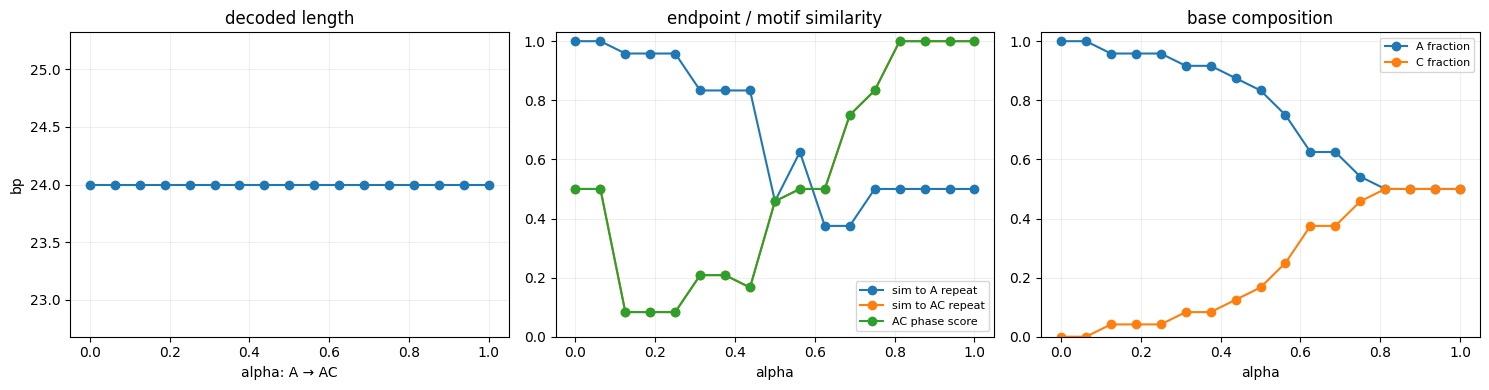

a=0.00 len=24 simA=1.00 simAC=0.50 ACphase=0.50  AAAAAAAAAAAAAAAAAAAAAAAA
a=0.12 len=24 simA=0.96 simAC=0.08 ACphase=0.08  AAAAAAAAAAAAAAAAAAAAAAAC
a=0.25 len=24 simA=0.96 simAC=0.08 ACphase=0.08  AAAAAAAAAAAAAAAAAAAAAAAC
a=0.38 len=24 simA=0.83 simAC=0.21 ACphase=0.21  AACAAAAAAAAAAAAAAAAAAAAC
a=0.50 len=24 simA=0.46 simAC=0.46 ACphase=0.46  ACAACAAAAAACAAAAAAAAAAAC
a=0.62 len=24 simA=0.38 simAC=0.50 ACphase=0.50  ACAACCACAAACACAAACACAAAC
a=0.75 len=24 simA=0.50 simAC=0.83 ACphase=0.83  ACAAACACACACACACACACACAC
a=0.88 len=24 simA=0.50 simAC=1.00 ACphase=1.00  ACACACACACACACACACACACAC
a=1.00 len=24 simA=0.50 simAC=1.00 ACphase=1.00  ACACACACACACACACACACACAC


In [74]:
def motif_identity_interpolation(start_seq='A' * 24, end_seq='AC' * 12, steps=17):
    enc = encode_decode([start_seq, end_seq])
    z0, z1 = enc['latent'][0], enc['latent'][1]
    u0, u1 = float(enc['usage'][0]), float(enc['usage'][1])
    rows = []
    for alpha in np.linspace(0, 1, steps):
        z = (1-alpha) * z0 + alpha * z1
        usage = (1-alpha) * u0 + alpha * u1
        decoded, dec_len = decode_latent(z, usage=usage)
        rows.append({
            'alpha': alpha,
            'decoded': decoded,
            'decoded_len': dec_len,
            'sim_A': ratio(start_seq, decoded),
            'sim_AC': ratio(end_seq, decoded),
            'A_fraction': decoded.count('A') / max(1, len(decoded)),
            'C_fraction': decoded.count('C') / max(1, len(decoded)),
            'AC_phase_score': ratio(('AC' * ((dec_len + 1)//2))[:dec_len], decoded),
        })
    return rows

rows = motif_identity_interpolation('A' * 24, 'AC' * 12, steps=17)
alphas = np.array([r['alpha'] for r in rows])
lengths = np.array([r['decoded_len'] for r in rows])
sim_A = np.array([r['sim_A'] for r in rows])
sim_AC = np.array([r['sim_AC'] for r in rows])
a_frac = np.array([r['A_fraction'] for r in rows])
c_frac = np.array([r['C_fraction'] for r in rows])
phase = np.array([r['AC_phase_score'] for r in rows])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(alphas, lengths, marker='o')
axes[0].set_title('decoded length')
axes[0].set_xlabel('alpha: A → AC')
axes[0].set_ylabel('bp')
axes[0].grid(alpha=0.2)

axes[1].plot(alphas, sim_A, marker='o', label='sim to A repeat')
axes[1].plot(alphas, sim_AC, marker='o', label='sim to AC repeat')
axes[1].plot(alphas, phase, marker='o', label='AC phase score')
axes[1].set_ylim(0, 1.03)
axes[1].set_title('endpoint / motif similarity')
axes[1].set_xlabel('alpha')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

axes[2].plot(alphas, a_frac, marker='o', label='A fraction')
axes[2].plot(alphas, c_frac, marker='o', label='C fraction')
axes[2].set_ylim(0, 1.03)
axes[2].set_title('base composition')
axes[2].set_xlabel('alpha')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2)
plt.tight_layout()
plt.show()

for r in rows[::2]:
    print(f"a={r['alpha']:.2f} len={r['decoded_len']:02d} simA={r['sim_A']:.2f} simAC={r['sim_AC']:.2f} ACphase={r['AC_phase_score']:.2f}  {r['decoded']}")


## 4. Latent dimension sweep

Perturb one latent coordinate at a time, decode, and rank dimensions by the sequence properties they change. This is the quickest way to find candidate axes for length, GC, repeat phase, and general editability.


LATENT DIM SWEEP: AAAAAAAAAAAAAAAAAAAAAAAA


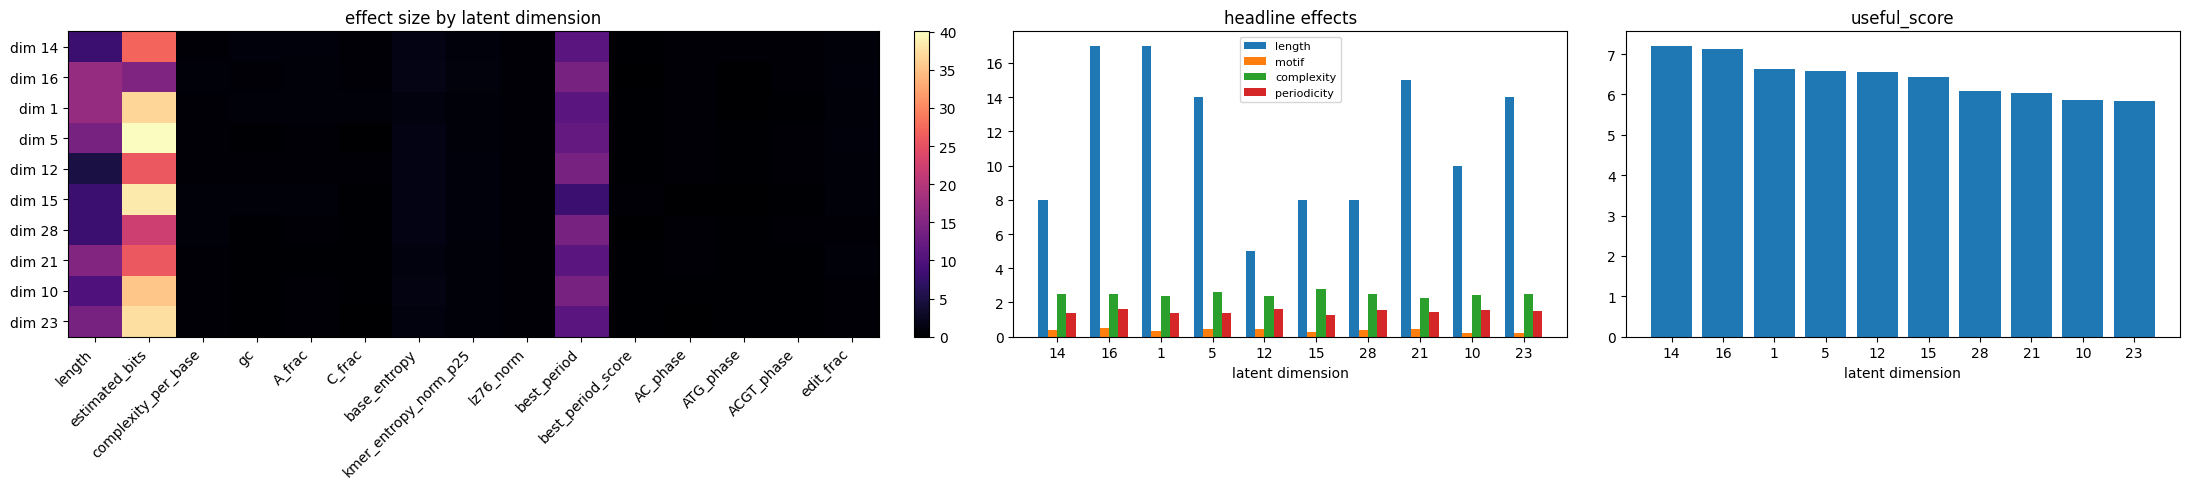

base input  : AAAAAAAAAAAAAAAAAAAAAAAA
base decoded: AAAAAAAAAAAAAAAAAAAAAAAA usage: 0.848

Top dimensions:
dim 14 | score 7.20 | len 8.0, motif 0.37, comp 2.47, period 1.37, edit 0.77, stable 0.86
dim 16 | score 7.13 | len 17.0, motif 0.51, comp 2.49, period 1.64, edit 0.79, stable 0.98
dim 01 | score 6.63 | len 17.0, motif 0.35, comp 2.37, period 1.41, edit 0.71, stable 0.81
dim 05 | score 6.58 | len 14.0, motif 0.46, comp 2.61, period 1.36, edit 0.82, stable 0.92
dim 12 | score 6.56 | len 5.0, motif 0.46, comp 2.40, period 1.63, edit 0.65, stable 0.85
dim 15 | score 6.44 | len 8.0, motif 0.29, comp 2.81, period 1.29, edit 0.65, stable 0.84
dim 28 | score 6.09 | len 8.0, motif 0.39, comp 2.47, period 1.55, edit 0.51, stable 0.91
dim 21 | score 6.05 | len 15.0, motif 0.43, comp 2.28, period 1.46, edit 0.71, stable 0.87
dim 10 | score 5.87 | len 10.0, motif 0.20, comp 2.41, period 1.57, edit 0.43, stable 0.82
dim 23 | score 5.84 | len 14.0, motif 0.24, comp 2.51, period 1.51, edit 0.49

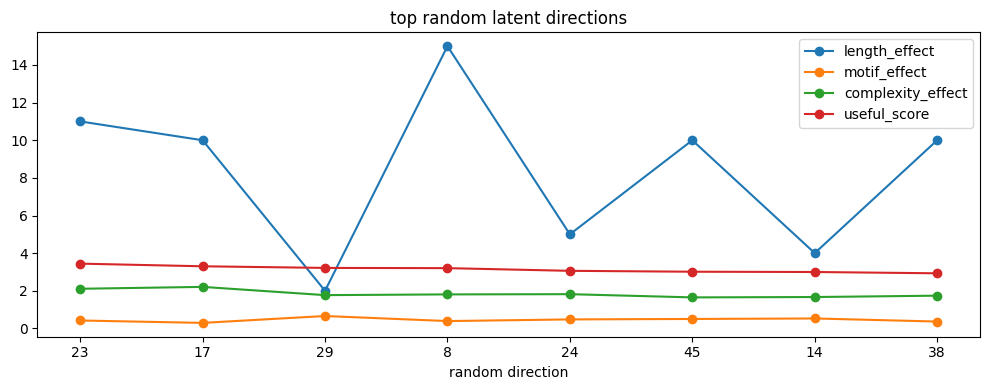

Random direction traces:

--- dir 23 score 3.44 ---
-4sd | len=18 bits~33.2 period=16 score=0.94 edit=0.52  CCAAAGAAACTAACAATC
-3sd | len=20 bits~35.7 period=15 score=0.95 edit=0.45  ACAAAGAAACTAACAATCAA
-2sd | len=21 bits~30.2 period=15 score=0.95 edit=0.38  ACAAAAAAAAAAACAATCAAA
-1sd | len=23 bits~22.0 period=01 score=0.96 edit=0.06  AAAAAAAAAAAAAAAAAAAAACA
+0sd | len=24 bits~14.0 period=01 score=1.00 edit=0.00  AAAAAAAAAAAAAAAAAAAAAAAA
+1sd | len=26 bits~14.2 period=01 score=1.00 edit=0.04  AAAAAAAAAAAAAAAAAAAAAAAAAA
+2sd | len=27 bits~14.3 period=01 score=1.00 edit=0.06  AAAAAAAAAAAAAAAAAAAAAAAAAAA
+3sd | len=28 bits~25.3 period=01 score=0.96 edit=0.08  AAAAAAAAAAAAAAAAAAAAAAGAAAAA
+4sd | len=29 bits~25.4 period=01 score=0.97 edit=0.09  AAAAAAAAAAAAAAAAAAAAAAGAAAAAA

--- dir 17 score 3.30 ---
-4sd | len=29 bits~35.8 period=04 score=0.90 edit=0.58  ATAAATAAATAAAAAAATAAAAAAAAAAA
-3sd | len=28 bits~34.9 period=10 score=0.86 edit=0.31  ACAAATAAATAAAAAAAAAAAAAAAAAA
-2sd | len=27 bits~30

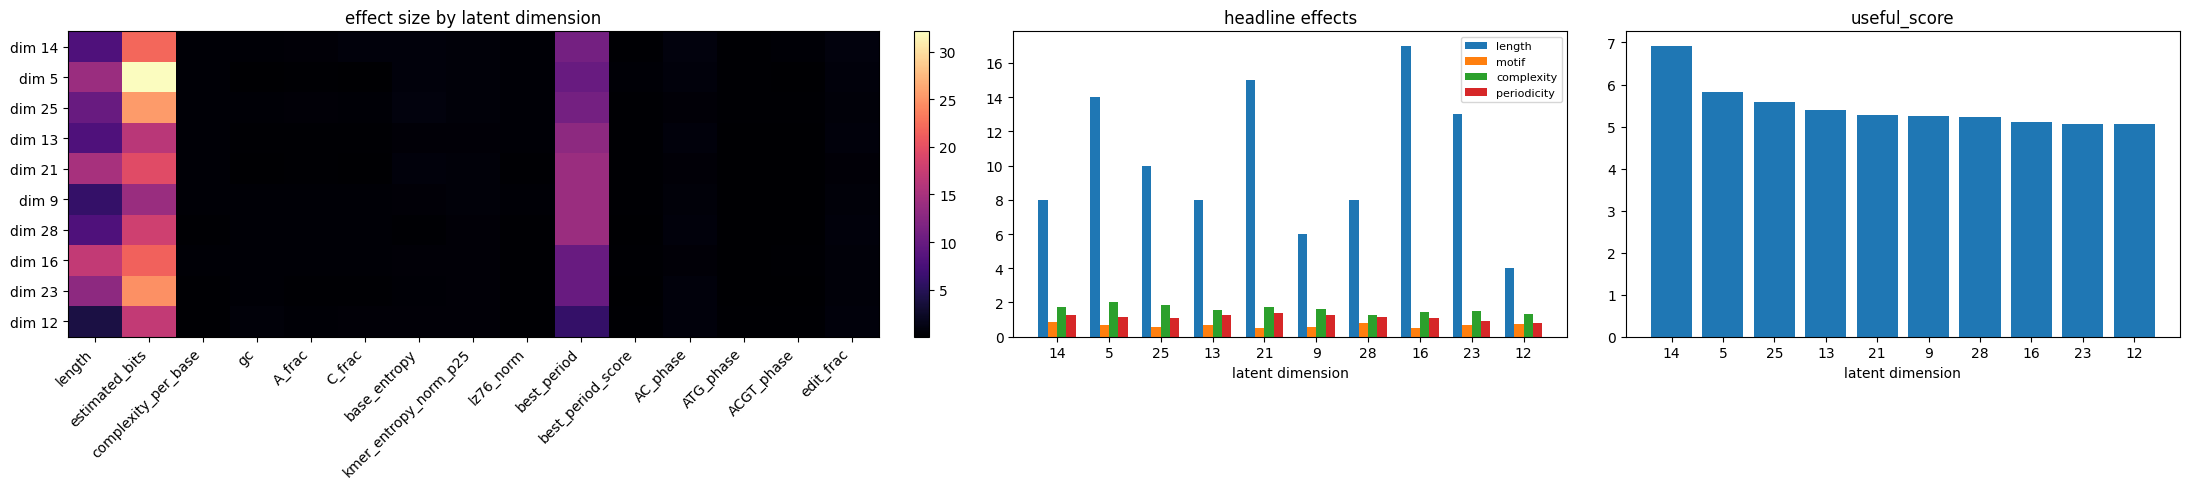

base input  : ACACACACACACACACACACACAC
base decoded: ACACACACACACACACACACACAC usage: 0.844

Top dimensions:
dim 14 | score 6.92 | len 8.0, motif 0.85, comp 1.71, period 1.28, edit 0.84, stable 0.88
dim 05 | score 5.82 | len 14.0, motif 0.69, comp 2.04, period 1.17, edit 0.73, stable 0.84
dim 25 | score 5.57 | len 10.0, motif 0.55, comp 1.85, period 1.09, edit 0.66, stable 0.83
dim 13 | score 5.39 | len 8.0, motif 0.70, comp 1.56, period 1.29, edit 0.73, stable 0.96
dim 21 | score 5.27 | len 15.0, motif 0.48, comp 1.74, period 1.36, edit 0.53, stable 0.97
dim 09 | score 5.25 | len 6.0, motif 0.57, comp 1.60, period 1.29, edit 0.60, stable 0.86
dim 28 | score 5.23 | len 8.0, motif 0.79, comp 1.27, period 1.16, edit 0.77, stable 0.96
dim 16 | score 5.10 | len 17.0, motif 0.53, comp 1.46, period 1.11, edit 0.64, stable 0.89
dim 23 | score 5.07 | len 13.0, motif 0.69, comp 1.48, period 0.94, edit 0.66, stable 0.98
dim 12 | score 5.05 | len 4.0, motif 0.73, comp 1.31, period 0.79, edit 0.72,

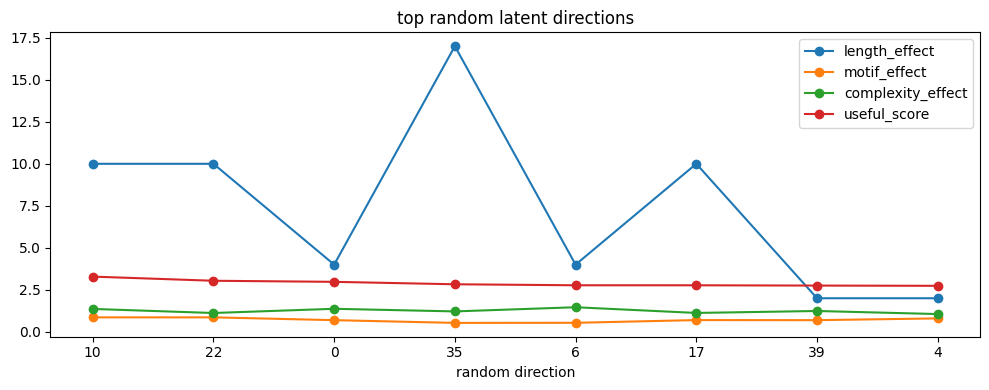

Random direction traces:

--- dir 10 score 3.29 ---
-4sd | len=29 bits~54.2 period=14 score=0.90 edit=0.85  AAGTAGATAGCTAGATAGATAGCTACATC
-3sd | len=28 bits~50.8 period=12 score=0.89 edit=0.42  ACGCACACAACTACATCCACAACTACAT
-2sd | len=27 bits~38.9 period=12 score=0.93 edit=0.37  ACACACACAAACACACACACACCCACA
-1sd | len=25 bits~27.5 period=02 score=1.00 edit=0.02  ACACACACACACACACACACACACA
+0sd | len=24 bits~27.1 period=02 score=1.00 edit=0.00  ACACACACACACACACACACACAC
+1sd | len=23 bits~26.6 period=02 score=1.00 edit=0.02  ACACACACACACACACACACACA
+2sd | len=21 bits~30.2 period=02 score=0.90 edit=0.16  ATACACACACACACACACACA
+3sd | len=20 bits~31.1 period=02 score=0.90 edit=0.18  GTACACACACACACACACAC
+4sd | len=19 bits~34.0 period=06 score=0.79 edit=0.67  GTACATACACAAACACACA

--- dir 22 score 3.04 ---
-4sd | len=19 bits~30.4 period=02 score=0.74 edit=0.26  AGACACACCCACACCCCCC
-3sd | len=20 bits~32.2 period=02 score=0.85 edit=0.23  AGACACACACACACCCACCC
-2sd | len=21 bits~31.9 period=02 score

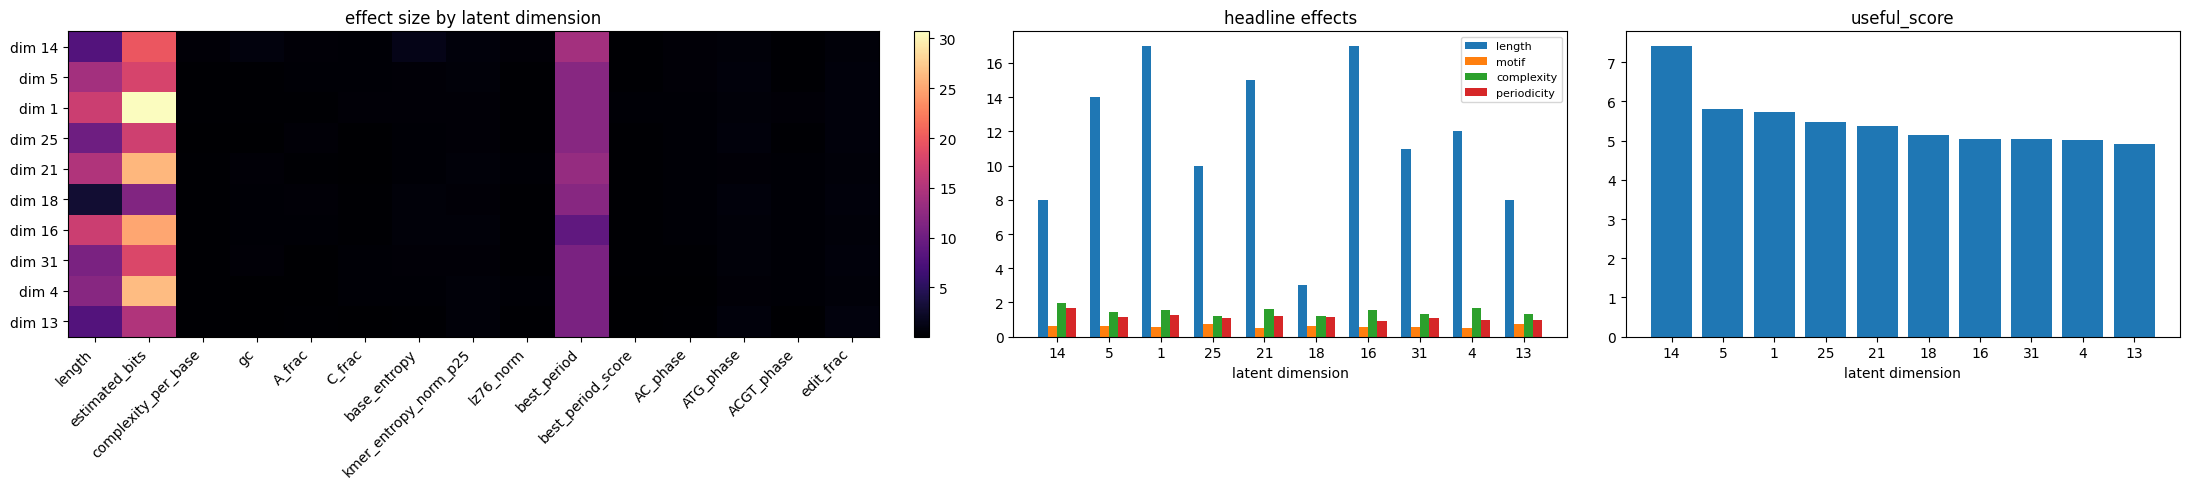

base input  : ATGATGATGATGATGATGATGATG
base decoded: ATGATGATGATGATGATGATGATG usage: 0.849

Top dimensions:
dim 14 | score 7.42 | len 8.0, motif 0.62, comp 1.98, period 1.67, edit 0.62, stable 0.88
dim 05 | score 5.81 | len 14.0, motif 0.65, comp 1.44, period 1.18, edit 0.72, stable 0.92
dim 01 | score 5.73 | len 17.0, motif 0.57, comp 1.55, period 1.28, edit 0.76, stable 0.86
dim 25 | score 5.47 | len 10.0, motif 0.75, comp 1.24, period 1.11, edit 0.73, stable 0.87
dim 21 | score 5.37 | len 15.0, motif 0.50, comp 1.60, period 1.23, edit 0.55, stable 0.87
dim 18 | score 5.15 | len 3.0, motif 0.65, comp 1.20, period 1.14, edit 0.70, stable 0.81
dim 16 | score 5.05 | len 17.0, motif 0.55, comp 1.59, period 0.91, edit 0.56, stable 0.91
dim 31 | score 5.05 | len 11.0, motif 0.57, comp 1.31, period 1.11, edit 0.65, stable 0.87
dim 04 | score 5.01 | len 12.0, motif 0.50, comp 1.69, period 1.00, edit 0.57, stable 0.92
dim 13 | score 4.92 | len 8.0, motif 0.75, comp 1.32, period 0.99, edit 0.7

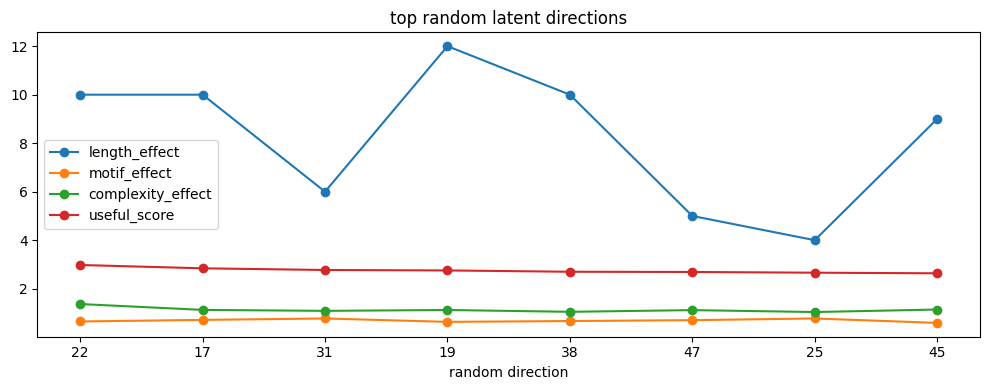

Random direction traces:

--- dir 22 score 2.98 ---
-4sd | len=19 bits~36.9 period=16 score=0.84 edit=0.63  AGGAAGATAATAACCCTCC
-3sd | len=20 bits~39.6 period=09 score=0.75 edit=0.68  AGGAAGATAATGACCATCCT
-2sd | len=22 bits~39.4 period=06 score=0.91 edit=0.22  AAGATGATAATGATAATGATAC
-1sd | len=23 bits~40.3 period=03 score=0.91 edit=0.11  ACGATGATGATGATGATGATGCT
+0sd | len=24 bits~35.9 period=03 score=1.00 edit=0.00  ATGATGATGATGATGATGATGATG
+1sd | len=26 bits~42.8 period=03 score=0.96 edit=0.08  ATGATGATGATGATGATGATGTTGAT
+2sd | len=27 bits~47.0 period=12 score=0.96 edit=0.14  ATGATGATGTTGATGATTATGTTGATG
+3sd | len=28 bits~43.1 period=07 score=0.82 edit=0.62  GTGATGTTGTTTTTGATTTTTTTTTTTA
+4sd | len=29 bits~37.6 period=08 score=0.86 edit=0.58  GTTATTTTGTTTTTTATTTTTTTTTTTTT

--- dir 17 score 2.84 ---
-4sd | len=29 bits~48.9 period=12 score=0.90 edit=0.47  ATGAATGAATTAATAATTATTTTAATGAA
-3sd | len=28 bits~51.4 period=12 score=0.89 edit=0.65  ATGAATGCGTTAATGATTATATTAATGA
-2sd | len=27 bits~

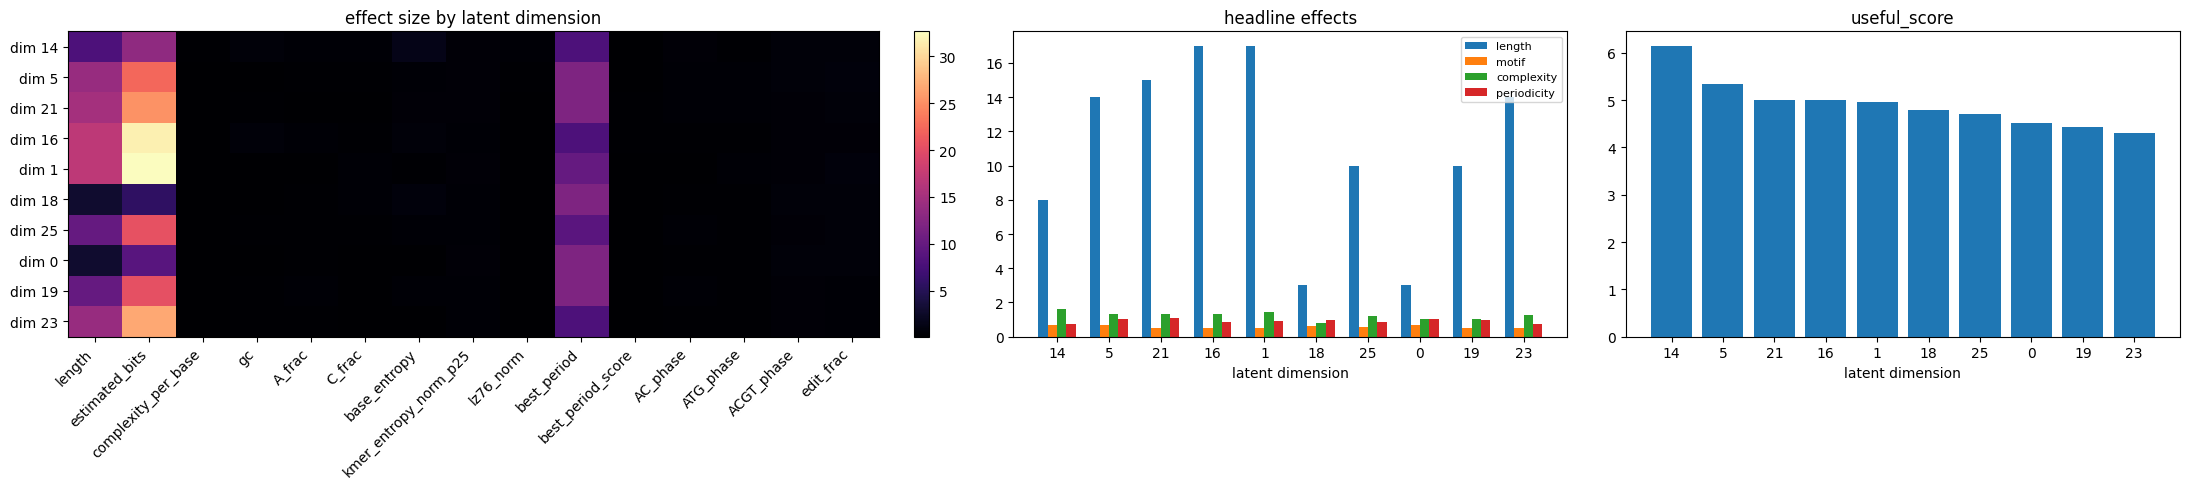

base input  : ACGTACGTACGTACGTACGTACGT
base decoded: ACGTACGTACGTACGTACGTACGT usage: 0.842

Top dimensions:
dim 14 | score 6.15 | len 8.0, motif 0.68, comp 1.61, period 0.73, edit 0.69, stable 0.94
dim 05 | score 5.34 | len 14.0, motif 0.71, comp 1.35, period 1.04, edit 0.75, stable 0.94
dim 21 | score 5.01 | len 15.0, motif 0.52, comp 1.33, period 1.11, edit 0.60, stable 0.89
dim 16 | score 5.00 | len 17.0, motif 0.50, comp 1.32, period 0.83, edit 0.57, stable 0.90
dim 01 | score 4.97 | len 17.0, motif 0.53, comp 1.42, period 0.93, edit 0.74, stable 0.91
dim 18 | score 4.78 | len 3.0, motif 0.61, comp 0.81, period 0.98, edit 0.62, stable 0.92
dim 25 | score 4.70 | len 10.0, motif 0.59, comp 1.21, period 0.87, edit 0.66, stable 0.82
dim 00 | score 4.52 | len 3.0, motif 0.70, comp 1.00, period 1.04, edit 0.70, stable 0.88
dim 19 | score 4.43 | len 10.0, motif 0.48, comp 1.03, period 0.96, edit 0.43, stable 0.91
dim 23 | score 4.30 | len 14.0, motif 0.52, comp 1.24, period 0.74, edit 0.4

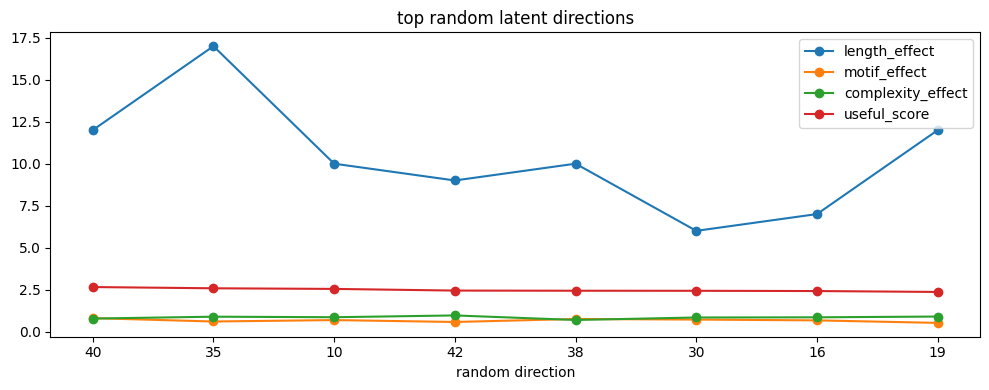

Random direction traces:

--- dir 40 score 2.65 ---
-4sd | len=30 bits~58.0 period=12 score=0.77 edit=0.78  ACGTGGATACGCTCGTGCGCCCGCCCGTAC
-3sd | len=29 bits~55.6 period=12 score=0.86 edit=0.55  ACGTGGGTACGCCCGTGCGTCCGCCCGTA
-2sd | len=27 bits~48.7 period=04 score=0.93 edit=0.10  ACGTACGTACGTCCGTACGTACGTCCG
-1sd | len=26 bits~43.8 period=04 score=1.00 edit=0.04  ACGTACGTACGTACGTACGTACGTAC
+0sd | len=24 bits~41.6 period=04 score=1.00 edit=0.00  ACGTACGTACGTACGTACGTACGT
+1sd | len=23 bits~39.9 period=04 score=1.00 edit=0.02  ACGTACGTACGTACGTACGTACG
+2sd | len=21 bits~38.3 period=04 score=0.95 edit=0.11  ACGTACGTACGTACGTATGTA
+3sd | len=20 bits~37.9 period=04 score=0.85 edit=0.32  ACGTACGTACATACATATGT
+4sd | len=18 bits~33.6 period=12 score=0.94 edit=0.43  ACATTCGTACATACATAT

--- dir 35 score 2.58 ---
-4sd | len=15 bits~29.4 period=15 score=1.00 edit=0.69  ACATGTGGACGTGCG
-3sd | len=17 bits~33.4 period=08 score=0.82 edit=0.41  ACATGTGTACGTGCGTG
-2sd | len=20 bits~36.4 period=04 score=0.90

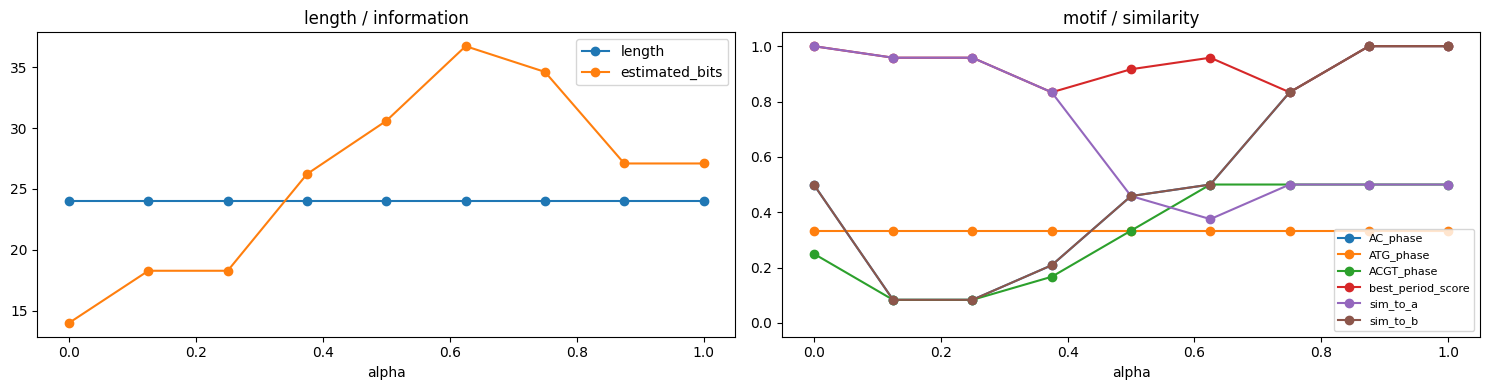

A input/decoded: AAAAAAAAAAAAAAAAAAAAAAAA => AAAAAAAAAAAAAAAAAAAAAAAA usage 0.848
B input/decoded: ACACACACACACACACACACACAC => ACACACACACACACACACACACAC usage 0.844

a=0.00 len=24 bits~14.0 period=01 per_score=1.00 AC=0.50 ATG=0.33 simA=1.00 simB=0.50  AAAAAAAAAAAAAAAAAAAAAAAA
a=0.12 len=24 bits~18.3 period=01 per_score=0.96 AC=0.08 ATG=0.33 simA=0.96 simB=0.08  AAAAAAAAAAAAAAAAAAAAAAAC
a=0.25 len=24 bits~18.3 period=01 per_score=0.96 AC=0.08 ATG=0.33 simA=0.96 simB=0.08  AAAAAAAAAAAAAAAAAAAAAAAC
a=0.38 len=24 bits~26.2 period=01 per_score=0.83 AC=0.21 ATG=0.33 simA=0.83 simB=0.21  AACAAAAAAAAAAAAAAAAAAAAC
a=0.50 len=24 bits~30.6 period=07 per_score=0.92 AC=0.46 ATG=0.33 simA=0.46 simB=0.46  ACAACAAAAAACAAAAAAAAAAAC
a=0.62 len=24 bits~36.7 period=06 per_score=0.96 AC=0.50 ATG=0.33 simA=0.38 simB=0.50  ACAACCACAAACACAAACACAAAC
a=0.75 len=24 bits~34.6 period=02 per_score=0.83 AC=0.83 ATG=0.33 simA=0.50 simB=0.83  ACAAACACACACACACACACACAC
a=0.88 len=24 bits~27.1 period=02 per_score=1.00 AC

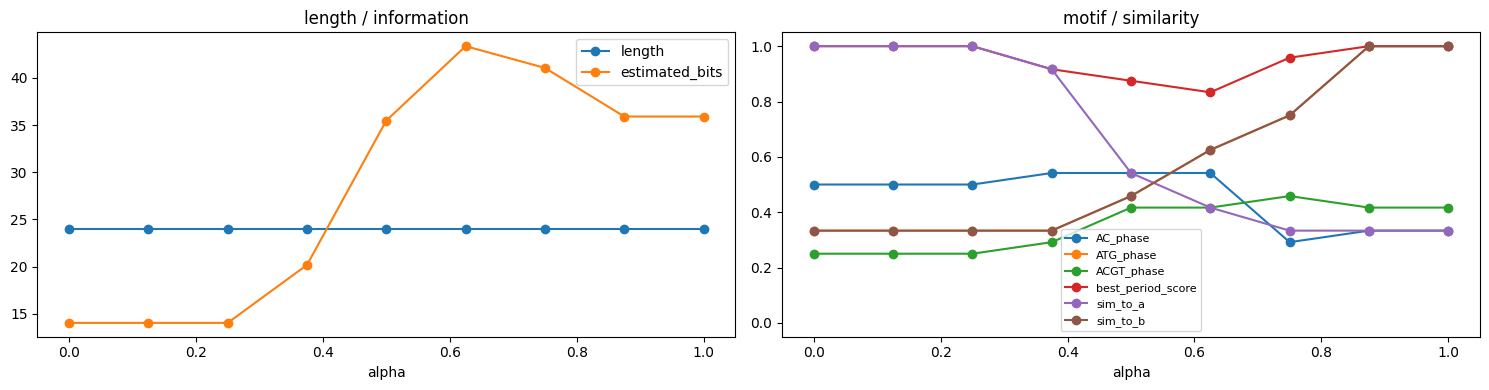

A input/decoded: AAAAAAAAAAAAAAAAAAAAAAAA => AAAAAAAAAAAAAAAAAAAAAAAA usage 0.848
B input/decoded: ATGATGATGATGATGATGATGATG => ATGATGATGATGATGATGATGATG usage 0.849

a=0.00 len=24 bits~14.0 period=01 per_score=1.00 AC=0.50 ATG=0.33 simA=1.00 simB=0.33  AAAAAAAAAAAAAAAAAAAAAAAA
a=0.12 len=24 bits~14.0 period=01 per_score=1.00 AC=0.50 ATG=0.33 simA=1.00 simB=0.33  AAAAAAAAAAAAAAAAAAAAAAAA
a=0.25 len=24 bits~14.0 period=01 per_score=1.00 AC=0.50 ATG=0.33 simA=1.00 simB=0.33  AAAAAAAAAAAAAAAAAAAAAAAA
a=0.38 len=24 bits~20.2 period=01 per_score=0.92 AC=0.54 ATG=0.33 simA=0.92 simB=0.33  ACAAAAAAAAAAAAAAAAAAAAAA
a=0.50 len=24 bits~35.5 period=06 per_score=0.88 AC=0.54 ATG=0.46 simA=0.54 simB=0.46  ACAAAGAAAAAAATAAAGAAAAAA
a=0.62 len=24 bits~43.4 period=06 per_score=0.83 AC=0.54 ATG=0.62 simA=0.42 simB=0.62  ACGATGAAGATAATAATGAAGATA
a=0.75 len=24 bits~41.1 period=09 per_score=0.96 AC=0.29 ATG=0.75 simA=0.33 simB=0.75  ATGATGACGATGATGATGATGATG
a=0.88 len=24 bits~35.9 period=03 per_score=1.00 AC

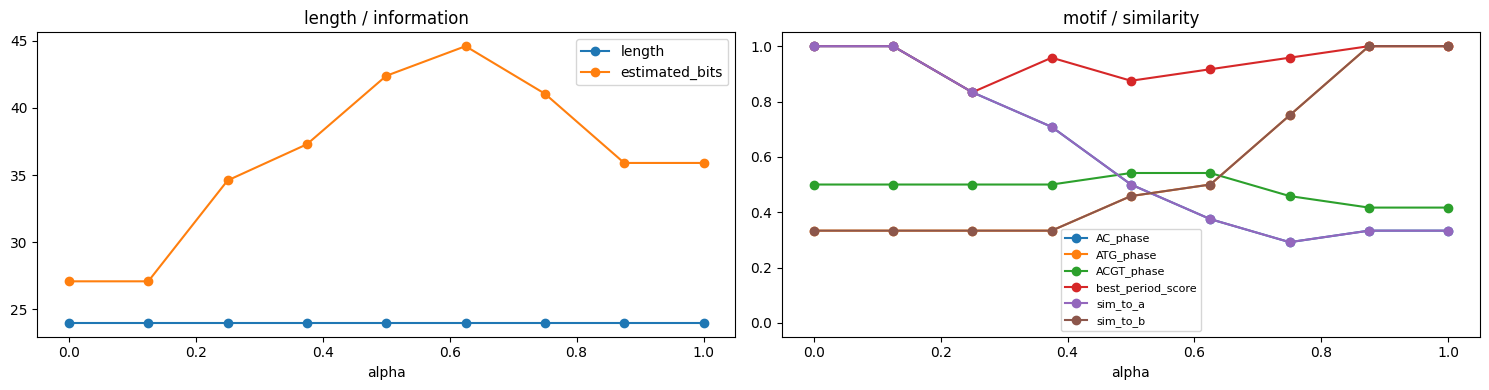

A input/decoded: ACACACACACACACACACACACAC => ACACACACACACACACACACACAC usage 0.844
B input/decoded: ATGATGATGATGATGATGATGATG => ATGATGATGATGATGATGATGATG usage 0.849

a=0.00 len=24 bits~27.1 period=02 per_score=1.00 AC=1.00 ATG=0.33 simA=1.00 simB=0.33  ACACACACACACACACACACACAC
a=0.12 len=24 bits~27.1 period=02 per_score=1.00 AC=1.00 ATG=0.33 simA=1.00 simB=0.33  ACACACACACACACACACACACAC
a=0.25 len=24 bits~34.6 period=02 per_score=0.83 AC=0.83 ATG=0.33 simA=0.83 simB=0.33  ACAAACACACACACACACACACAC
a=0.38 len=24 bits~37.3 period=12 per_score=0.96 AC=0.71 ATG=0.33 simA=0.71 simB=0.33  ACAACCACACCCACAACCACAACC
a=0.50 len=24 bits~42.4 period=12 per_score=0.88 AC=0.50 ATG=0.46 simA=0.50 simB=0.46  ATGACGACAACCACAACCACAACC
a=0.62 len=24 bits~44.6 period=14 per_score=0.92 AC=0.38 ATG=0.50 simA=0.38 simB=0.50  ATGAAGACGACAATAATGACAACA
a=0.75 len=24 bits~41.1 period=09 per_score=0.96 AC=0.29 ATG=0.75 simA=0.29 simB=0.75  ATGATGACGATGATGATGATGATG
a=0.88 len=24 bits~35.9 period=03 per_score=1.00 AC

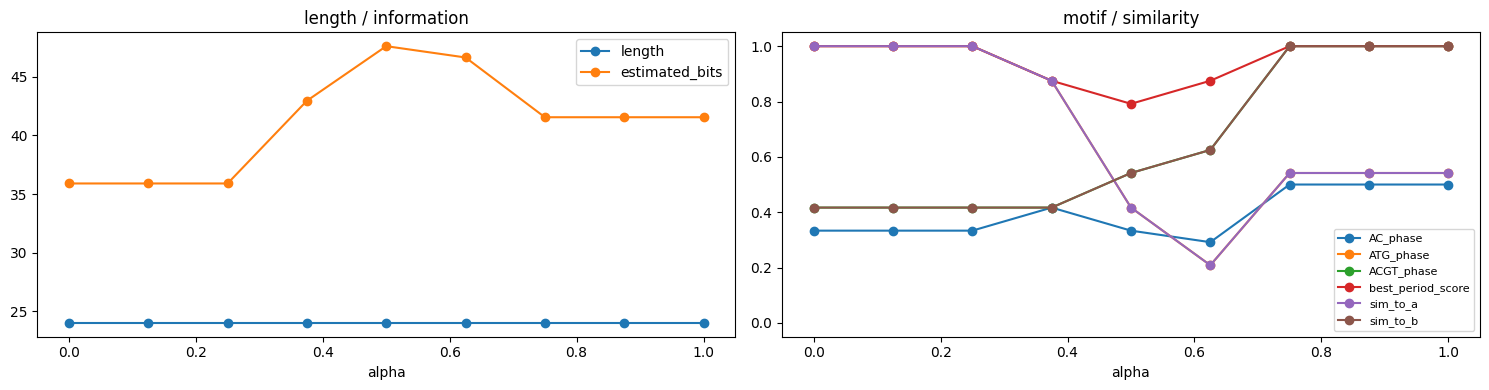

A input/decoded: ATGATGATGATGATGATGATGATG => ATGATGATGATGATGATGATGATG usage 0.849
B input/decoded: ACGTACGTACGTACGTACGTACGT => ACGTACGTACGTACGTACGTACGT usage 0.842

a=0.00 len=24 bits~35.9 period=03 per_score=1.00 AC=0.33 ATG=1.00 simA=1.00 simB=0.42  ATGATGATGATGATGATGATGATG
a=0.12 len=24 bits~35.9 period=03 per_score=1.00 AC=0.33 ATG=1.00 simA=1.00 simB=0.42  ATGATGATGATGATGATGATGATG
a=0.25 len=24 bits~35.9 period=03 per_score=1.00 AC=0.33 ATG=1.00 simA=1.00 simB=0.42  ATGATGATGATGATGATGATGATG
a=0.38 len=24 bits~43.0 period=03 per_score=0.88 AC=0.42 ATG=0.88 simA=0.88 simB=0.42  ATGATGATGAAAATGATGATGCTG
a=0.50 len=24 bits~47.6 period=08 per_score=0.79 AC=0.33 ATG=0.42 simA=0.42 simB=0.54  ACGATGGTACACATGATCATGCTT
a=0.62 len=24 bits~46.7 period=12 per_score=0.88 AC=0.29 ATG=0.21 simA=0.21 simB=0.62  ACGAACGTACATATGTTCGTACAT
a=0.75 len=24 bits~41.6 period=04 per_score=1.00 AC=0.50 ATG=0.54 simA=0.54 simB=1.00  ACGTACGTACGTACGTACGTACGT
a=0.88 len=24 bits~41.6 period=04 per_score=1.00 AC

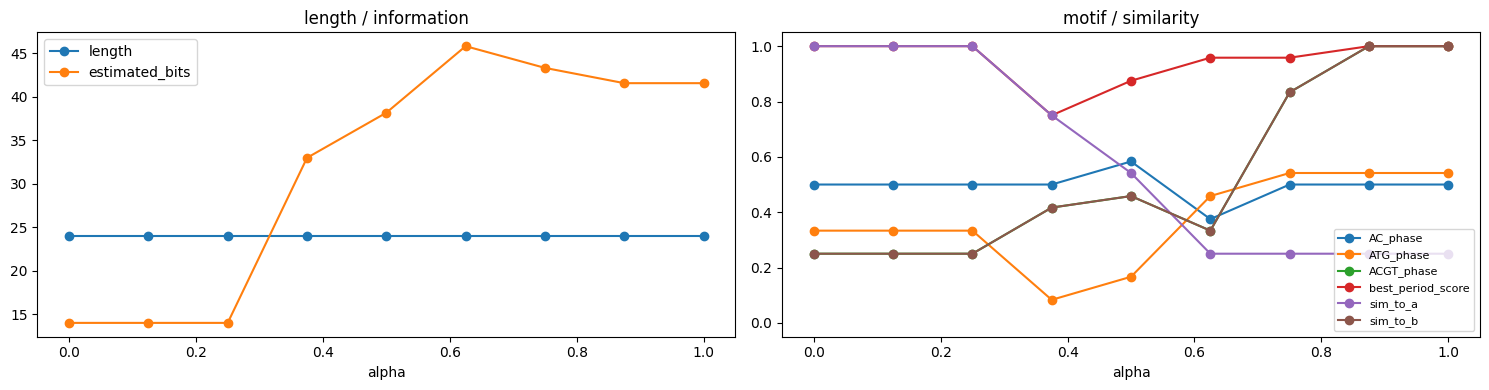

A input/decoded: AAAAAAAAAAAAAAAAAAAAAAAA => AAAAAAAAAAAAAAAAAAAAAAAA usage 0.848
B input/decoded: ACGTACGTACGTACGTACGTACGT => ACGTACGTACGTACGTACGTACGT usage 0.842

a=0.00 len=24 bits~14.0 period=01 per_score=1.00 AC=0.50 ATG=0.33 simA=1.00 simB=0.25  AAAAAAAAAAAAAAAAAAAAAAAA
a=0.12 len=24 bits~14.0 period=01 per_score=1.00 AC=0.50 ATG=0.33 simA=1.00 simB=0.25  AAAAAAAAAAAAAAAAAAAAAAAA
a=0.25 len=24 bits~14.0 period=01 per_score=1.00 AC=0.50 ATG=0.33 simA=1.00 simB=0.25  AAAAAAAAAAAAAAAAAAAAAAAA
a=0.38 len=24 bits~33.0 period=01 per_score=0.75 AC=0.50 ATG=0.08 simA=0.75 simB=0.42  ACAAAAAAAAAAACAAACAAACAT
a=0.50 len=24 bits~38.2 period=06 per_score=0.88 AC=0.58 ATG=0.17 simA=0.54 simB=0.46  ACAAACACAAATACAAACAAACAT
a=0.62 len=24 bits~45.8 period=12 per_score=0.96 AC=0.38 ATG=0.46 simA=0.25 simB=0.33  ACGAACGCACATACGAACGTACAT
a=0.75 len=24 bits~43.3 period=12 per_score=0.96 AC=0.50 ATG=0.54 simA=0.25 simB=0.83  ACGAACGTACGTACGTACGTACGT
a=0.88 len=24 bits~41.6 period=04 per_score=1.00 AC

In [75]:
import math
import zlib
import difflib
import itertools
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None


# -----------------------------
# Basic similarity / utilities
# -----------------------------

DNA = "ACGT"

def _ratio(a, b):
    # Uses your existing ratio() if present; otherwise difflib fallback.
    if "ratio" in globals():
        return float(ratio(a, b))
    return difflib.SequenceMatcher(None, a, b).ratio()

def base_fractions(seq):
    n = max(1, len(seq))
    return {b: seq.count(b) / n for b in DNA}

def shannon_from_counts(counts):
    total = sum(counts.values())
    if total <= 0:
        return 0.0
    h = 0.0
    for c in counts.values():
        if c:
            p = c / total
            h -= p * math.log2(p)
    return h

def shannon_base_entropy(seq):
    return shannon_from_counts(Counter(seq))

def normalised_base_entropy(seq):
    return shannon_base_entropy(seq) / 2.0

def gc_skew(seq):
    g = seq.count("G")
    c = seq.count("C")
    return (g - c) / max(1, g + c)

def at_skew(seq):
    a = seq.count("A")
    t = seq.count("T")
    return (a - t) / max(1, a + t)

def longest_run(seq):
    if not seq:
        return 0
    best = 1
    cur = 1
    for i in range(1, len(seq)):
        if seq[i] == seq[i - 1]:
            cur += 1
            best = max(best, cur)
        else:
            cur = 1
    return best

def longest_run_frac(seq):
    return longest_run(seq) / max(1, len(seq))

def transition_rate(seq):
    if len(seq) < 2:
        return 0.0
    return sum(seq[i] != seq[i - 1] for i in range(1, len(seq))) / (len(seq) - 1)

def zlib_bits_adjusted(seq):
    # Header-adjusted proxy. Noisy for very short strings, useful as a rough feature.
    raw = seq.encode("ascii")
    empty = zlib.compress(b"", level=9)
    comp = zlib.compress(raw, level=9)
    return max(0.0, 8.0 * (len(comp) - len(empty)))

def zlib_bits_per_base(seq):
    return zlib_bits_adjusted(seq) / max(1, len(seq))

def lz76_complexity(seq):
    # Simple Lempel-Ziv parsing complexity: number of new phrases.
    # Useful as a short-sequence complexity proxy.
    n = len(seq)
    if n == 0:
        return 0
    phrases = set()
    i = 0
    c = 0
    while i < n:
        j = i + 1
        while j <= n and seq[i:j] in phrases:
            j += 1
        phrases.add(seq[i:j])
        c += 1
        i = j
    return c

def lz76_norm(seq):
    n = len(seq)
    if n <= 1:
        return 0.0
    # Approx normalisation: random strings scale roughly n / log_sigma(n).
    sigma = 4.0
    return min(1.5, lz76_complexity(seq) * math.log(n, sigma) / n)


# -----------------------------
# K-mer / multiscale complexity
# -----------------------------

def kmer_counts(seq, k):
    if len(seq) < k or k <= 0:
        return Counter()
    return Counter(seq[i:i+k] for i in range(len(seq) - k + 1))

def kmer_entropy(seq, k):
    return shannon_from_counts(kmer_counts(seq, k))

def kmer_entropy_per_base(seq, k):
    # Raw k-mer entropy divided by k. Not enough alone, but useful.
    if len(seq) < k:
        return np.nan
    return kmer_entropy(seq, k) / k

def kmer_entropy_norm(seq, k):
    """
    Normalise k-mer entropy against the maximum possible entropy for the number
    of observed k-mers. This avoids the trap where large k makes every k-mer
    unique and falsely looks maximally structured.
    """
    n_obs = len(seq) - k + 1
    if n_obs <= 0:
        return np.nan
    h = kmer_entropy(seq, k)
    max_h = min(math.log2(max(1, n_obs)), 2.0 * k)
    return h / max(1e-8, max_h)

def multiscale_kmer_features(seq, ks=(1, 2, 3, 4, 5, 6, 8, 10, 12)):
    vals = {}
    norm_vals = []
    per_base_vals = []
    for k in ks:
        hn = kmer_entropy_norm(seq, k)
        hb = kmer_entropy_per_base(seq, k)
        vals[f"k{k}_entropy_norm"] = float(hn) if not np.isnan(hn) else np.nan
        vals[f"k{k}_entropy_per_base"] = float(hb) if not np.isnan(hb) else np.nan
        if not np.isnan(hn):
            norm_vals.append(hn)
        if not np.isnan(hb):
            per_base_vals.append(hb)

    if norm_vals:
        vals["kmer_entropy_norm_mean"] = float(np.mean(norm_vals))
        vals["kmer_entropy_norm_min"] = float(np.min(norm_vals))
        vals["kmer_entropy_norm_p25"] = float(np.percentile(norm_vals, 25))
        vals["kmer_entropy_norm_max"] = float(np.max(norm_vals))
    else:
        vals["kmer_entropy_norm_mean"] = vals["kmer_entropy_norm_min"] = vals["kmer_entropy_norm_p25"] = vals["kmer_entropy_norm_max"] = np.nan

    if per_base_vals:
        vals["kmer_entropy_per_base_mean"] = float(np.mean(per_base_vals))
        vals["kmer_entropy_per_base_min"] = float(np.min(per_base_vals))
    else:
        vals["kmer_entropy_per_base_mean"] = vals["kmer_entropy_per_base_min"] = np.nan

    return vals


# -----------------------------
# Repeat / motif structure
# -----------------------------

def repeat_template(motif, length):
    if len(motif) == 0:
        return ""
    return (motif * ((length + len(motif) - 1) // len(motif)))[:length]

def motif_phase_score(seq, motif):
    return _ratio(seq, repeat_template(motif, len(seq)))

def consensus_period_template(seq, period):
    """
    Best period-k template by taking the majority base at each phase.
    This detects periodicity without assuming the motif is seq[:k].
    """
    if not seq or period <= 0:
        return "", ""
    motif = []
    for phase in range(period):
        chars = [seq[i] for i in range(phase, len(seq), period)]
        if chars:
            motif.append(Counter(chars).most_common(1)[0][0])
        else:
            motif.append("N")
    motif = "".join(motif)
    return motif, repeat_template(motif, len(seq))

def best_periodicity(seq, max_period=16):
    if not seq:
        return {
            "best_period": 0,
            "best_period_score": 0.0,
            "best_period_motif": "",
            "best_period_reps": 0.0,
        }

    best = None
    for p in range(1, min(max_period, len(seq)) + 1):
        motif, template = consensus_period_template(seq, p)
        score = _ratio(seq, template)

        # Mild penalty for long motifs, so ACGTACGT is still periodic,
        # but random unique long motif doesn't trivially win.
        penalised = score - 0.015 * (p - 1)

        row = (penalised, score, p, motif, template)
        if best is None or row > best:
            best = row

    _pen, score, p, motif, template = best
    return {
        "best_period": float(p),
        "best_period_score": float(score),
        "best_period_motif": motif,
        "best_period_reps": float(len(seq) / max(1, p)),
    }

def motif_bank_scores(seq):
    motifs = [
        "A", "C", "G", "T",
        "AC", "AT", "AG", "CG", "GT", "CT",
        "ATG", "CGA", "TAC", "GAA", "CTG",
        "ACGT", "TGCA", "AAAA", "CCCC",
    ]
    return {f"motif_{m}_phase": motif_phase_score(seq, m) for m in motifs}


# -----------------------------
# Sequence property vector
# -----------------------------

def seq_properties(seq, reference=None):
    frac = base_fractions(seq)
    periodic = best_periodicity(seq, max_period=min(16, max(1, len(seq))))
    kmer = multiscale_kmer_features(seq)
    motifs = motif_bank_scores(seq)

    props = {
        "length": float(len(seq)),
        "gc": frac["G"] + frac["C"],
        "A_frac": frac["A"],
        "C_frac": frac["C"],
        "G_frac": frac["G"],
        "T_frac": frac["T"],
        "base_entropy": shannon_base_entropy(seq),
        "base_entropy_norm": normalised_base_entropy(seq),
        "gc_skew": gc_skew(seq),
        "at_skew": at_skew(seq),
        "longest_run": float(longest_run(seq)),
        "longest_run_frac": longest_run_frac(seq),
        "transition_rate": transition_rate(seq),
        "zlib_bits": zlib_bits_adjusted(seq),
        "zlib_bits_per_base": zlib_bits_per_base(seq),
        "lz76_complexity": float(lz76_complexity(seq)),
        "lz76_norm": lz76_norm(seq),
        "AC_phase": motif_phase_score(seq, "AC"),
        "AT_phase": motif_phase_score(seq, "AT"),
        "ATG_phase": motif_phase_score(seq, "ATG"),
        "ACGT_phase": motif_phase_score(seq, "ACGT"),
        **periodic,
        **kmer,
        **motifs,
    }

    # A crude information budget estimate: conservative mixture of base entropy,
    # k-mer complexity and compression/LZ proxies.
    # Not "truth", just useful for plotting.
    complexity_per_base = np.nanmean([
        props["base_entropy"] / 2.0,
        props["kmer_entropy_norm_p25"],
        min(1.0, props["zlib_bits_per_base"] / 2.0),
        min(1.0, props["lz76_norm"]),
    ])
    props["complexity_per_base"] = float(complexity_per_base)
    props["estimated_bits"] = float(len(seq) * 2.0 * complexity_per_base)

    if reference is not None:
        props["edit_frac"] = 1.0 - _ratio(reference, seq)
        props["similarity_to_ref"] = _ratio(reference, seq)
        props["len_delta_ref"] = float(len(seq) - len(reference))
    else:
        props["edit_frac"] = np.nan
        props["similarity_to_ref"] = np.nan
        props["len_delta_ref"] = np.nan

    return props


# -----------------------------
# Calibration / decoding helpers
# -----------------------------

def calibration_sequences():
    seqs = []
    motifs = [
        "A", "C", "G", "T",
        "AC", "AT", "CG", "GT", "AG", "CT",
        "ATG", "CGA", "TAC", "GAA", "CTG",
        "ACGT", "TGCA",
    ]
    for motif in motifs:
        for reps in [1, 2, 3, 4, 6, 8, 12, 16, 20, 24, 32]:
            s = (motif * reps)[:args.seq_len]
            if 2 <= len(s) <= args.seq_len:
                seqs.append(s)

    # Add some biased/random-ish examples for latent std calibration.
    rng = np.random.default_rng(1)
    for L in [8, 12, 16, 24, 32, 48, min(64, args.seq_len)]:
        if L <= args.seq_len:
            for alphabet in ["ACGT", "AAAAC", "GGGCCAT", "CTTCC", "AAGGA"]:
                for _ in range(6):
                    seqs.append("".join(rng.choice(list(alphabet), size=L)))

    return seqs

def calibration_latent_std():
    calib = calibration_sequences()
    lat = encode_decode(calib)["latent"].numpy()
    std = lat.std(axis=0)

    nonzero = std[std > 1e-6]
    floor = np.median(nonzero) * 0.25 if len(nonzero) else 0.1
    return np.maximum(std, floor)

def decode_many_latents(latents, usages):
    seqs = []
    for z, u in zip(latents, usages):
        seq, _ = decode_latent(np.asarray(z), usage=float(u))
        seqs.append(seq)
    return seqs


# -----------------------------
# Latent dim sweep
# -----------------------------

DEFAULT_METRICS = [
    "length",
    "estimated_bits",
    "complexity_per_base",
    "gc",
    "A_frac",
    "C_frac",
    "G_frac",
    "T_frac",
    "base_entropy",
    "kmer_entropy_norm_p25",
    "zlib_bits_per_base",
    "lz76_norm",
    "longest_run_frac",
    "transition_rate",
    "best_period",
    "best_period_score",
    "best_period_reps",
    "AC_phase",
    "AT_phase",
    "ATG_phase",
    "ACGT_phase",
    "edit_frac",
]

def metric_effect(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return 0.0
    return float(vals.max() - vals.min())

def monotonicity_score(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) < 3:
        return np.nan
    diffs = np.diff(vals)
    if np.all(np.abs(diffs) < 1e-9):
        return 0.0
    return float(abs(np.sum(np.sign(diffs))) / max(1, len(diffs)))

def endpoint_stability_score(trace):
    # How much do endpoints decode as coherent/simple things?
    p0 = seq_properties(trace[0])
    p1 = seq_properties(trace[-1])
    return float(0.5 * (p0["best_period_score"] + p1["best_period_score"]))

def latent_dim_sweep(
    base_seq="A" * 24,
    sweep_values=(-4, -3, -2, -1, 0, 1, 2, 3, 4),
    top_k=12,
    metrics=DEFAULT_METRICS,
):
    enc = encode_decode([base_seq])
    z0 = enc["latent"][0].numpy().copy()
    usage = float(enc["usage"][0])
    base_decoded = enc["decoded"][0]
    latent_std = calibration_latent_std()

    rows = []
    traces = {}
    props_by_dim = {}

    for dim in range(z0.shape[0]):
        decoded = []
        props = []
        for value in sweep_values:
            z = z0.copy()
            z[dim] += float(value) * latent_std[dim]
            seq, _ = decode_latent(z, usage=usage)
            decoded.append(seq)
            props.append(seq_properties(seq, reference=base_decoded))

        traces[dim] = decoded
        props_by_dim[dim] = props

        row = {"dim": dim}
        total = 0.0
        for name in metrics:
            vals = np.array([p.get(name, np.nan) for p in props], dtype=float)
            eff = metric_effect(vals)
            row[name + "_effect"] = eff
            row[name + "_monotonicity"] = monotonicity_score(vals)
            total += eff

        # More interpretable aggregate scores.
        row["total_effect"] = total
        row["length_effect"] = row.get("length_effect", 0.0)
        row["motif_effect"] = max(
            row.get("AC_phase_effect", 0.0),
            row.get("AT_phase_effect", 0.0),
            row.get("ATG_phase_effect", 0.0),
            row.get("ACGT_phase_effect", 0.0),
        )
        row["composition_effect"] = (
            row.get("A_frac_effect", 0.0)
            + row.get("C_frac_effect", 0.0)
            + row.get("G_frac_effect", 0.0)
            + row.get("T_frac_effect", 0.0)
        )
        row["complexity_effect"] = (
            row.get("complexity_per_base_effect", 0.0)
            + row.get("estimated_bits_effect", 0.0) / max(1.0, args.seq_len)
            + row.get("lz76_norm_effect", 0.0)
            + row.get("kmer_entropy_norm_p25_effect", 0.0)
        )
        row["periodicity_effect"] = (
            row.get("best_period_effect", 0.0) / 16.0
            + row.get("best_period_score_effect", 0.0)
            + row.get("best_period_reps_effect", 0.0) / max(1.0, args.seq_len)
        )
        row["endpoint_stability"] = endpoint_stability_score(decoded)
        row["useful_score"] = (
            0.8 * row["length_effect"] / max(1.0, args.seq_len)
            + 1.5 * row["motif_effect"]
            + 0.8 * row["composition_effect"]
            + 1.0 * row["complexity_effect"]
            + 1.0 * row["periodicity_effect"]
            + 0.5 * row["endpoint_stability"]
            + 0.5 * row.get("edit_frac_effect", 0.0)
        )
        rows.append(row)

    rows = sorted(rows, key=lambda r: r["useful_score"], reverse=True)
    return {
        "base_seq": base_seq,
        "base_decoded": base_decoded,
        "usage": usage,
        "sweep_values": list(sweep_values),
        "rows": rows,
        "top": rows[:top_k],
        "traces": traces,
        "props_by_dim": props_by_dim,
        "metrics": metrics,
        "latent_std": latent_std,
    }


# -----------------------------
# Random direction sweep
# -----------------------------

def random_direction_sweep(
    base_seq="A" * 24,
    n_dirs=64,
    sweep_values=(-4, -3, -2, -1, 0, 1, 2, 3, 4),
    top_k=10,
    seed=1,
):
    enc = encode_decode([base_seq])
    z0 = enc["latent"][0].numpy().copy()
    usage = float(enc["usage"][0])
    base_decoded = enc["decoded"][0]
    latent_std = calibration_latent_std()

    rng = np.random.default_rng(seed)
    rows = []
    traces = {}

    for d in range(n_dirs):
        direction = rng.normal(size=z0.shape)
        direction = direction / max(1e-8, np.linalg.norm(direction))
        direction = direction * latent_std

        decoded = []
        props = []
        for value in sweep_values:
            z = z0 + float(value) * direction
            seq, _ = decode_latent(z, usage=usage)
            decoded.append(seq)
            props.append(seq_properties(seq, reference=base_decoded))

        row = {"dir": d}
        for name in DEFAULT_METRICS:
            vals = [p.get(name, np.nan) for p in props]
            row[name + "_effect"] = metric_effect(vals)

        row["length_effect"] = row.get("length_effect", 0.0)
        row["motif_effect"] = max(
            row.get("AC_phase_effect", 0.0),
            row.get("AT_phase_effect", 0.0),
            row.get("ATG_phase_effect", 0.0),
            row.get("ACGT_phase_effect", 0.0),
        )
        row["complexity_effect"] = (
            row.get("complexity_per_base_effect", 0.0)
            + row.get("lz76_norm_effect", 0.0)
            + row.get("kmer_entropy_norm_p25_effect", 0.0)
        )
        row["endpoint_stability"] = endpoint_stability_score(decoded)
        row["useful_score"] = (
            row["length_effect"] / max(1.0, args.seq_len)
            + 1.5 * row["motif_effect"]
            + row["complexity_effect"]
            + 0.5 * row["endpoint_stability"]
        )
        rows.append(row)
        traces[d] = decoded

    rows = sorted(rows, key=lambda r: r["useful_score"], reverse=True)
    return {
        "base_seq": base_seq,
        "base_decoded": base_decoded,
        "usage": usage,
        "sweep_values": list(sweep_values),
        "rows": rows,
        "top": rows[:top_k],
        "traces": traces,
    }


# -----------------------------
# Pairwise interpolation
# -----------------------------

def interpolate_sequences(seq_a, seq_b, alphas=np.linspace(0, 1, 9), usage_mode="linear"):
    enc = encode_decode([seq_a, seq_b])
    za = enc["latent"][0].numpy().copy()
    zb = enc["latent"][1].numpy().copy()
    ua = float(enc["usage"][0])
    ub = float(enc["usage"][1])
    da = enc["decoded"][0]
    db = enc["decoded"][1]

    rows = []
    decoded = []
    for a in alphas:
        z = (1 - a) * za + a * zb
        if usage_mode == "linear":
            u = (1 - a) * ua + a * ub
        elif usage_mode == "a":
            u = ua
        elif usage_mode == "b":
            u = ub
        else:
            u = float(usage_mode)

        seq, _ = decode_latent(z, usage=u)
        decoded.append(seq)
        props = seq_properties(seq)
        props.update({
            "alpha": float(a),
            "seq": seq,
            "sim_to_a": _ratio(seq, da),
            "sim_to_b": _ratio(seq, db),
            "edit_to_a": 1.0 - _ratio(seq, da),
            "edit_to_b": 1.0 - _ratio(seq, db),
        })
        rows.append(props)

    return {
        "seq_a": seq_a,
        "seq_b": seq_b,
        "decoded_a": da,
        "decoded_b": db,
        "usage_a": ua,
        "usage_b": ub,
        "alphas": list(alphas),
        "rows": rows,
        "decoded": decoded,
    }

def print_interpolation(result, max_width=120):
    print("A input/decoded:", result["seq_a"], "=>", result["decoded_a"], "usage", round(result["usage_a"], 3))
    print("B input/decoded:", result["seq_b"], "=>", result["decoded_b"], "usage", round(result["usage_b"], 3))
    print()
    for r in result["rows"]:
        seq = r["seq"]
        if len(seq) > max_width:
            seq = seq[:max_width] + "..."
        print(
            f"a={r['alpha']:.2f} "
            f"len={int(r['length']):02d} "
            f"bits~{r['estimated_bits']:.1f} "
            f"period={int(r['best_period']):02d} "
            f"per_score={r['best_period_score']:.2f} "
            f"AC={r['AC_phase']:.2f} ATG={r['ATG_phase']:.2f} "
            f"simA={r['sim_to_a']:.2f} simB={r['sim_to_b']:.2f}  "
            f"{seq}"
        )


# -----------------------------
# Plotting / reporting
# -----------------------------

def _rows_to_df(rows):
    if pd is None:
        return rows
    return pd.DataFrame(rows)

def plot_latent_dim_sweep(result, top_n=None):
    top = result["top"] if top_n is None else result["rows"][:top_n]
    dims = [r["dim"] for r in top]

    heat_metrics = [
        "length",
        "estimated_bits",
        "complexity_per_base",
        "gc",
        "A_frac",
        "C_frac",
        "base_entropy",
        "kmer_entropy_norm_p25",
        "lz76_norm",
        "best_period",
        "best_period_score",
        "AC_phase",
        "ATG_phase",
        "ACGT_phase",
        "edit_frac",
    ]
    mat = np.array([[r.get(m + "_effect", 0.0) for m in heat_metrics] for r in top], dtype=float)

    fig, axes = plt.subplots(1, 3, figsize=(22, 5), gridspec_kw={"width_ratios": [1.6, 1.0, 1.0]})

    im = axes[0].imshow(mat, aspect="auto", cmap="magma")
    axes[0].set_title("effect size by latent dimension")
    axes[0].set_yticks(range(len(dims)))
    axes[0].set_yticklabels([f"dim {d}" for d in dims])
    axes[0].set_xticks(range(len(heat_metrics)))
    axes[0].set_xticklabels(heat_metrics, rotation=45, ha="right")
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    x = np.arange(len(dims))
    headline = ["length_effect", "motif_effect", "complexity_effect", "periodicity_effect"]
    width = 0.18
    for i, metric in enumerate(headline):
        vals = [r.get(metric, 0.0) for r in top]
        axes[1].bar(x + (i - 1.5) * width, vals, width=width, label=metric.replace("_effect", ""))
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([str(d) for d in dims])
    axes[1].set_xlabel("latent dimension")
    axes[1].set_title("headline effects")
    axes[1].legend(fontsize=8)

    vals = [r.get("useful_score", 0.0) for r in top]
    axes[2].bar(x, vals)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels([str(d) for d in dims])
    axes[2].set_xlabel("latent dimension")
    axes[2].set_title("useful_score")

    plt.tight_layout()
    plt.show()

    print("base input  :", result["base_seq"])
    print("base decoded:", result["base_decoded"], "usage:", round(result["usage"], 3))
    print("\nTop dimensions:")
    for r in top:
        print(
            f"dim {r['dim']:02d} | score {r['useful_score']:.2f} | "
            f"len {r.get('length_effect', 0.0):.1f}, "
            f"motif {r.get('motif_effect', 0.0):.2f}, "
            f"comp {r.get('complexity_effect', 0.0):.2f}, "
            f"period {r.get('periodicity_effect', 0.0):.2f}, "
            f"edit {r.get('edit_frac_effect', 0.0):.2f}, "
            f"stable {r.get('endpoint_stability', 0.0):.2f}"
        )

    print("\nDecoded traces for top dimensions:")
    for r in top[:6]:
        dim = r["dim"]
        print(f"\n--- dim {dim:02d} ---")
        for value, seq in zip(result["sweep_values"], result["traces"][dim]):
            p = seq_properties(seq, reference=result["base_decoded"])
            print(
                f"{value:+g}sd | len={int(p['length']):02d} "
                f"bits~{p['estimated_bits']:.1f} "
                f"period={int(p['best_period']):02d} "
                f"score={p['best_period_score']:.2f} "
                f"AC={p['AC_phase']:.2f} ATG={p['ATG_phase']:.2f} "
                f"edit={p['edit_frac']:.2f}  {seq}"
            )

    df = _rows_to_df(result["rows"])
    return df

def plot_random_direction_sweep(result, top_n=8):
    top = result["rows"][:top_n]
    dirs = [r["dir"] for r in top]

    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(dirs))
    for metric in ["length_effect", "motif_effect", "complexity_effect", "useful_score"]:
        ax.plot(x, [r.get(metric, 0.0) for r in top], marker="o", label=metric)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d) for d in dirs])
    ax.set_xlabel("random direction")
    ax.set_title("top random latent directions")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Random direction traces:")
    for r in top[:5]:
        d = r["dir"]
        print(f"\n--- dir {d:02d} score {r['useful_score']:.2f} ---")
        for value, seq in zip(result["sweep_values"], result["traces"][d]):
            p = seq_properties(seq, reference=result["base_decoded"])
            print(
                f"{value:+g}sd | len={int(p['length']):02d} "
                f"bits~{p['estimated_bits']:.1f} "
                f"period={int(p['best_period']):02d} "
                f"score={p['best_period_score']:.2f} "
                f"edit={p['edit_frac']:.2f}  {seq}"
            )

    return _rows_to_df(result["rows"])

def plot_interpolation(result):
    alphas = [r["alpha"] for r in result["rows"]]
    metrics = ["length", "estimated_bits", "AC_phase", "ATG_phase", "ACGT_phase", "best_period_score", "sim_to_a", "sim_to_b"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    for m in ["length", "estimated_bits"]:
        axes[0].plot(alphas, [r[m] for r in result["rows"]], marker="o", label=m)
    axes[0].set_xlabel("alpha")
    axes[0].set_title("length / information")
    axes[0].legend()

    for m in ["AC_phase", "ATG_phase", "ACGT_phase", "best_period_score", "sim_to_a", "sim_to_b"]:
        axes[1].plot(alphas, [r[m] for r in result["rows"]], marker="o", label=m)
    axes[1].set_xlabel("alpha")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_title("motif / similarity")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print_interpolation(result)


# -----------------------------
# Convenience mega-analysis
# -----------------------------

def run_manifold_analysis(
    base_seqs=("A" * 24, "AC" * 12, "ATG" * 8, "ACGT" * 6),
    top_k=10,
    n_random_dirs=48,
):
    outputs = {}

    for base in base_seqs:
        print("\n" + "=" * 100)
        print("LATENT DIM SWEEP:", base)
        sweep = latent_dim_sweep(base_seq=base, top_k=top_k)
        df = plot_latent_dim_sweep(sweep, top_n=top_k)
        outputs[("dim_sweep", base)] = sweep

        print("\n" + "-" * 100)
        print("RANDOM DIRECTION SWEEP:", base)
        rd = random_direction_sweep(base_seq=base, n_dirs=n_random_dirs, top_k=min(8, top_k))
        plot_random_direction_sweep(rd, top_n=min(8, top_k))
        outputs[("random_dirs", base)] = rd

    pairs = [
        ("A" * 24, "AC" * 12),
        ("A" * 24, "ATG" * 8),
        ("AC" * 12, "ATG" * 8),
        ("ATG" * 8, "ACGT" * 6),
        ("A" * 24, "ACGT" * 6),
    ]

    for a, b in pairs:
        print("\n" + "=" * 100)
        print("PAIRWISE INTERPOLATION")
        interp = interpolate_sequences(a, b, alphas=np.linspace(0, 1, 9))
        plot_interpolation(interp)
        outputs[("interp", a, b)] = interp

    return outputs


# -----------------------------
# Run
# -----------------------------

analysis_outputs = run_manifold_analysis(
    base_seqs=("A" * 24, "AC" * 12, "ATG" * 8, "ACGT" * 6),
    top_k=10,
    n_random_dirs=48,
)

## 5. K-mer content feature probes

Generate sequences with varied mono-, di-, and tri-nucleotide content, encode them, then find which latent coordinates correlate with each compositional feature.

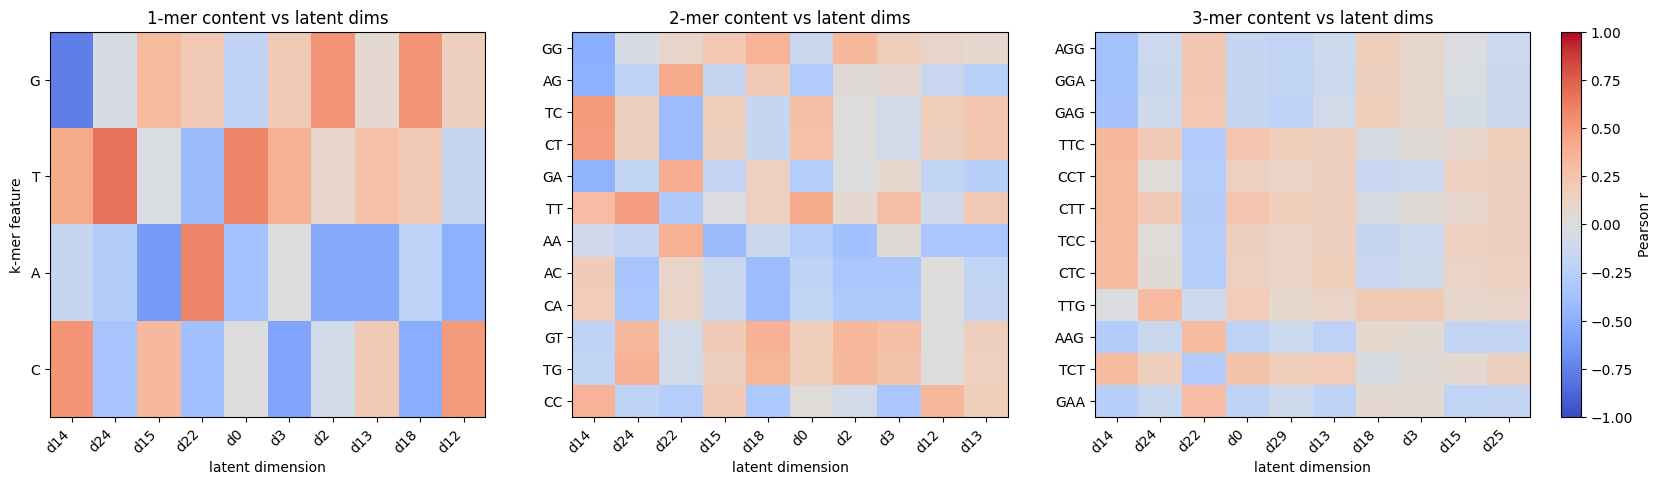

encoded 2162 synthetic feature-probe sequences

Top 1-mer feature axes:
    G: dim 14 r=-0.76, dim 18 r=+0.53, dim 02 r=+0.52
    T: dim 24 r=+0.67, dim 00 r=+0.58, dim 08 r=+0.43
    A: dim 15 r=-0.61, dim 22 r=+0.59, dim 02 r=-0.54
    C: dim 03 r=-0.56, dim 14 r=+0.52, dim 18 r=-0.51

Top 2-mer feature axes:
   GG: dim 14 r=-0.51, dim 18 r=+0.36, dim 02 r=+0.32
   AG: dim 14 r=-0.49, dim 22 r=+0.41, dim 00 r=-0.28
   TC: dim 14 r=+0.49, dim 22 r=-0.40, dim 00 r=+0.28
   CT: dim 14 r=+0.48, dim 22 r=-0.40, dim 00 r=+0.27
   GA: dim 14 r=-0.47, dim 22 r=+0.40, dim 00 r=-0.27
   TT: dim 24 r=+0.47, dim 00 r=+0.40, dim 22 r=-0.29
   AA: dim 15 r=-0.41, dim 22 r=+0.38, dim 02 r=-0.38
   AC: dim 18 r=-0.40, dim 24 r=-0.35, dim 02 r=-0.33
   CA: dim 18 r=-0.40, dim 24 r=-0.33, dim 03 r=-0.31
   GT: dim 18 r=+0.37, dim 02 r=+0.33, dim 24 r=+0.33

Top 3-mer feature axes:
  AGG: dim 14 r=-0.37, dim 22 r=+0.23, dim 29 r=-0.19
  GGA: dim 14 r=-0.36, dim 22 r=+0.22, dim 29 r=-0.19
  GAG: dim 14 

KeyError: 4

In [ ]:
import itertools

DNA = 'ACGT'

def kmer_fraction(seq, kmer):
    k = len(kmer)
    if len(seq) < k:
        return 0.0
    total = len(seq) - k + 1
    return sum(1 for i in range(total) if seq[i:i+k] == kmer) / max(1, total)

def all_kmers(k):
    return [''.join(x) for x in itertools.product(DNA, repeat=k)]

def feature_probe_sequences(n_random=160, repeat_counts=(3, 4, 6, 8, 10, 12, 16, 20, 24)):
    seqs = []

    # Pure repeats give clean k-mer axes.
    for k in [1, 2, 3]:
        for motif in all_kmers(k):
            # Skip fully redundant longer homopolymers for the repeat set; monomers cover those.
            if k > 1 and len(set(motif)) == 1:
                continue
            for reps in repeat_counts:
                s = (motif * reps)[:args.seq_len]
                if len(s) >= 3:
                    seqs.append(s)

    # Mixed segments avoid only learning pure-repeat corners.
    rng = np.random.default_rng(11)
    motif_pool = all_kmers(1) + all_kmers(2) + all_kmers(3)
    for _ in range(n_random):
        parts = []
        while len(''.join(parts)) < args.seq_len:
            motif = motif_pool[int(rng.integers(0, len(motif_pool)))]
            reps = int(rng.integers(1, 9))
            parts.append(motif * reps)
            if rng.random() < 0.35:
                parts.append(''.join(rng.choice(list(DNA), size=int(rng.integers(1, 8)))))
        length = int(rng.integers(max(8, args.seq_len // 3), args.seq_len + 1))
        seqs.append(''.join(parts)[:length])

    # Preserve order while removing duplicates.
    return list(dict.fromkeys(seqs))

def kmer_feature_matrix(seqs, k):
    feats = all_kmers(k)
    mat = np.array([[kmer_fraction(seq, feat) for feat in feats] for seq in seqs], dtype=float)
    return feats, mat

def pearson_corr_matrix(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x - x.mean(axis=0, keepdims=True)
    y = y - y.mean(axis=0, keepdims=True)
    x = x / (x.std(axis=0, keepdims=True) + 1e-8)
    y = y / (y.std(axis=0, keepdims=True) + 1e-8)
    return (x.T @ y) / max(1, x.shape[0] - 1)

def kmer_content_probe(top_features=12, top_dims=10):
    seqs = feature_probe_sequences()
    enc = encode_decode(seqs)
    z = enc['latent'].numpy()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    summaries = {}

    for ax, k in zip(axes, [1, 2, 3]):
        feats, feat_mat = kmer_feature_matrix(seqs, k)
        corr = pearson_corr_matrix(feat_mat, z)  # feature x latent_dim
        max_abs = np.max(np.abs(corr), axis=1)
        feat_order = np.argsort(-max_abs)[:top_features]
        dim_order = np.argsort(-np.max(np.abs(corr[feat_order]), axis=0))[:top_dims]
        shown = corr[feat_order][:, dim_order]

        im = ax.imshow(shown, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
        ax.set_title(f'{k}-mer content vs latent dims')
        ax.set_yticks(range(len(feat_order)))
        ax.set_yticklabels([feats[i] for i in feat_order])
        ax.set_xticks(range(len(dim_order)))
        ax.set_xticklabels([f'd{d}' for d in dim_order], rotation=45, ha='right')
        ax.set_xlabel('latent dimension')
        if k == 1:
            ax.set_ylabel('k-mer feature')
        summaries[k] = (feats, corr, feat_order, dim_order)

    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, label='Pearson r')
    plt.show()

    print(f'encoded {len(seqs)} synthetic feature-probe sequences')
    for k in [1, 2, 3]:
        feats, corr, feat_order, _ = summaries[k]
        print(f'\nTop {k}-mer feature axes:')
        for fi in feat_order[:10]:
            dim_rank = np.argsort(-np.abs(corr[fi]))[:3]
            desc = ', '.join(f'dim {d:02d} r={corr[fi, d]:+.2f}' for d in dim_rank)
            print(f'  {feats[fi]:>3s}: {desc}')
    return summaries

kmer_probe = kmer_content_probe(top_features=12, top_dims=10)


## 6. Causal k-mer feature interventions

Use the strongest dimensions found by the k-mer probe, then actually push those dimensions and decode. This separates correlation from causal control.

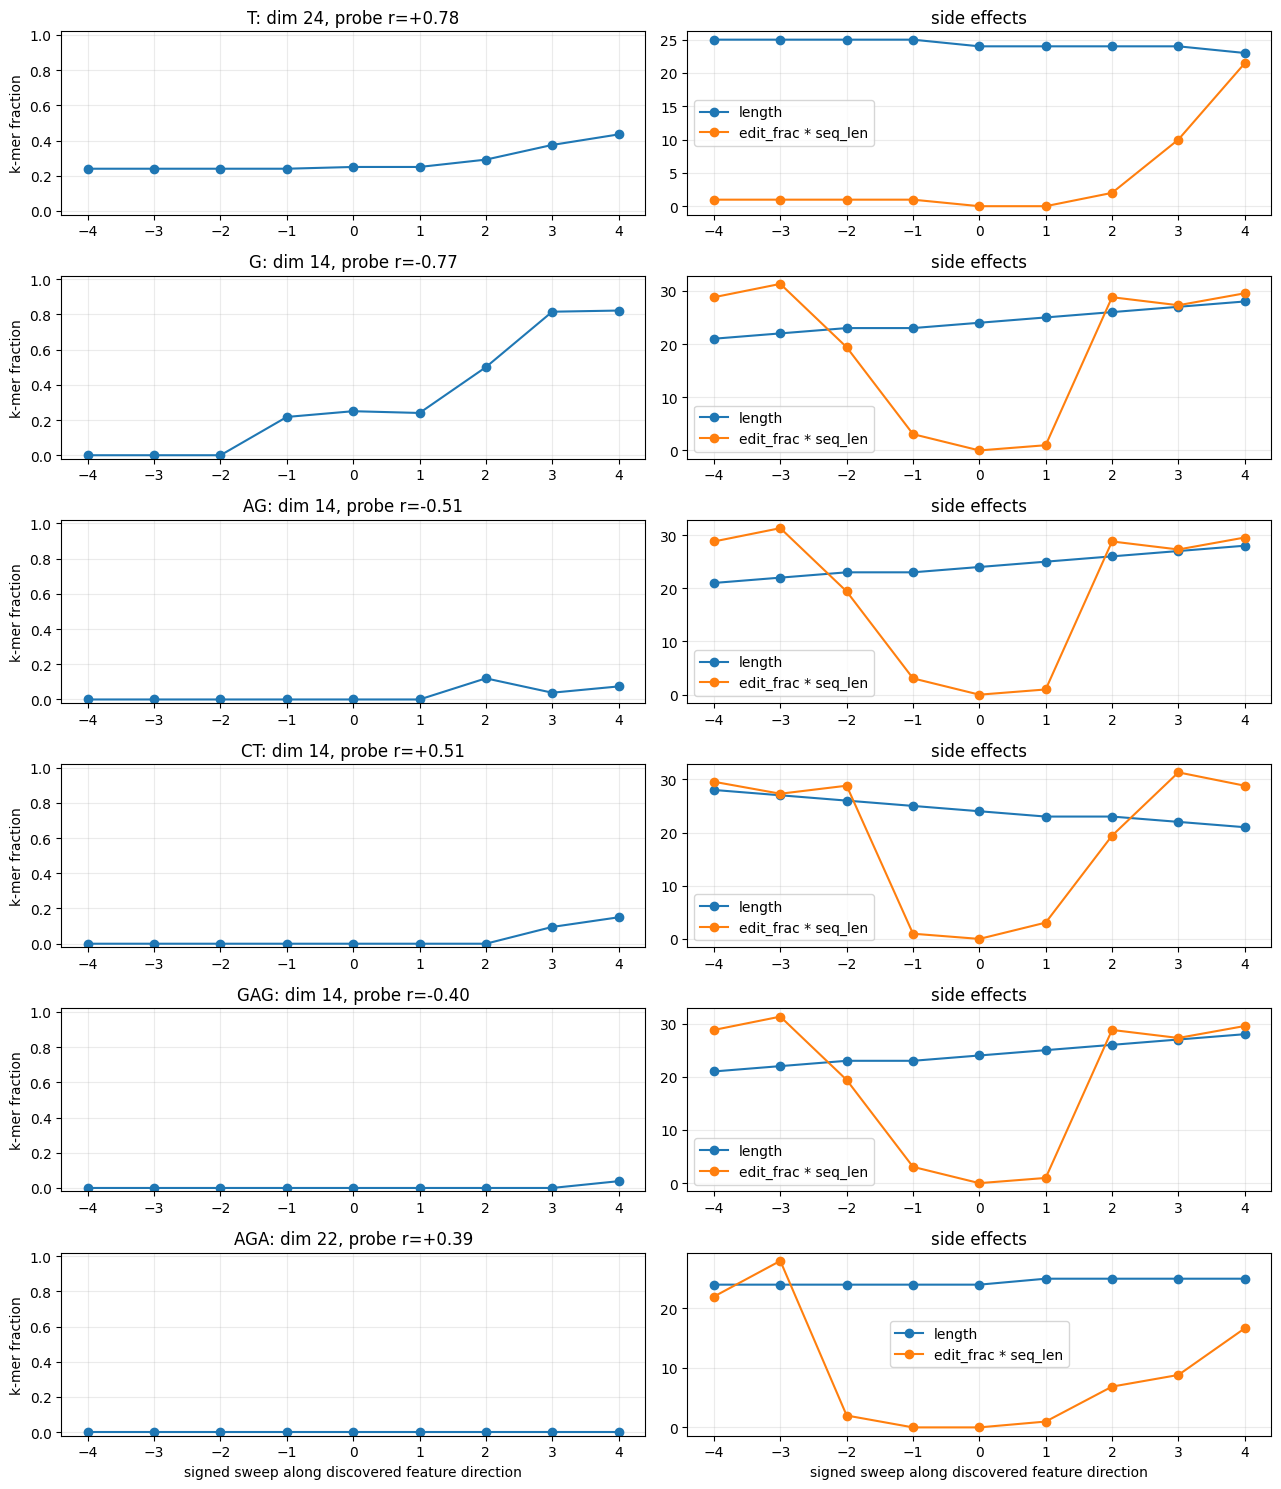

base input  : ACGTACGTACGTACGTACGTACGT
base decoded: ACGTACGTACGTACGTACGTACGT usage: 0.842

Causal intervention summary:
  G via dim 14 (probe r=-0.77) | frac 0.00->0.82 at alpha -4->+4
  low : ATTTTCATCCCTATCTTCCTT
  high: AGGAGGGGGGGTGGGTGGGGGGGTGGGG
  T via dim 24 (probe r=+0.78) | frac 0.24->0.43 at alpha -4->+4
  low : ACGTACGTACGTACGTACGTACGTA
  high: ATGTATGTACGTATGGTTGTAGT
 CT via dim 14 (probe r=+0.51) | frac 0.00->0.15 at alpha -4->+4
  low : AGGAGGGGGGGTGGGTGGGGGGGTGGGG
  high: ATTTTCATCCCTATCTTCCTT
 AG via dim 14 (probe r=-0.51) | frac 0.00->0.12 at alpha -4->+2
  low : ATTTTCATCCCTATCTTCCTT
  high: AAGTGCGTGCGTAGGTGGGTGCGTAG
GAG via dim 14 (probe r=-0.40) | frac 0.00->0.04 at alpha -4->+4
  low : ATTTTCATCCCTATCTTCCTT
  high: AGGAGGGGGGGTGGGTGGGGGGGTGGGG
AGA via dim 22 (probe r=+0.39) | frac 0.00->0.00 at alpha -4->-4
  low : ACGTTCGTCAGTACATATGCCAAT
  high: ACGTTCGTCAGTACATATGCCAAT


In [77]:
def choose_kmer_features_from_probe(kmer_probe, per_k=3):
    chosen = []
    for k in sorted(kmer_probe.keys()):
        feats, corr, feat_order, _ = kmer_probe[k]
        for fi in feat_order[:per_k]:
            chosen.append(feats[fi])
    return chosen

def best_dim_for_feature(feature, kmer_probe):
    k = len(feature)
    if k not in kmer_probe:
        raise ValueError(f'No k={k} probe results found. Run kmer_content_probe first.')
    feats, corr, _, _ = kmer_probe[k]
    if feature not in feats:
        raise ValueError(f'Feature {feature!r} not in k={k} feature list.')
    fi = feats.index(feature)
    dim = int(np.argmax(np.abs(corr[fi])))
    r = float(corr[fi, dim])
    direction = 1.0 if r >= 0 else -1.0
    return dim, r, direction

def latent_scale_from_probe_sequences():
    seqs = feature_probe_sequences(n_random=80)
    lat = encode_decode(seqs)['latent'].numpy()
    std = lat.std(axis=0)
    floor = np.median(std[std > 1e-6]) * 0.25 if np.any(std > 1e-6) else 0.1
    return np.maximum(std, floor)

def causal_kmer_interventions(features=None, base_seq=None, sweep=(-4, -3, -2, -1, 0, 1, 2, 3, 4), per_k=2):
    if 'kmer_probe' not in globals():
        raise RuntimeError('Run the k-mer content feature probe cell first so `kmer_probe` exists.')
    if features is None:
        features = choose_kmer_features_from_probe(kmer_probe, per_k=per_k)
    if base_seq is None:
        # Balanced-ish baseline: enough structure to decode cleanly, not already saturated for one feature.
        base_seq = ('ACGT' * ((args.seq_len + 3) // 4))[:24]

    enc = encode_decode([base_seq])
    z0 = enc['latent'][0].numpy().copy()
    usage = float(enc['usage'][0])
    base_decoded = enc['decoded'][0]
    scale = latent_scale_from_probe_sequences()

    rows = []
    n = len(features)
    fig, axes = plt.subplots(n, 2, figsize=(13, max(3, 2.5 * n)), squeeze=False)

    for row_i, feature in enumerate(features):
        dim, corr_r, direction = best_dim_for_feature(feature, kmer_probe)
        decoded = []
        feature_frac = []
        lengths = []
        gc = []
        edit = []

        for alpha in sweep:
            z = z0.copy()
            z[dim] += direction * float(alpha) * scale[dim]
            seq, dec_len = decode_latent(z, usage=usage)
            decoded.append(seq)
            feature_frac.append(kmer_fraction(seq, feature))
            lengths.append(dec_len)
            gc.append(base_fractions(seq)['G'] + base_fractions(seq)['C'])
            edit.append(1.0 - ratio(base_decoded, seq))

        axes[row_i, 0].plot(sweep, feature_frac, marker='o', label=f'{feature} fraction')
        axes[row_i, 0].set_title(f'{feature}: dim {dim}, probe r={corr_r:+.2f}')
        axes[row_i, 0].set_ylabel('k-mer fraction')
        axes[row_i, 0].set_ylim(-0.02, 1.02)
        axes[row_i, 0].grid(alpha=0.25)

        axes[row_i, 1].plot(sweep, lengths, marker='o', label='length')
        axes[row_i, 1].plot(sweep, np.array(edit) * max(1, args.seq_len), marker='o', label='edit_frac * seq_len')
        axes[row_i, 1].set_title('side effects')
        axes[row_i, 1].grid(alpha=0.25)
        axes[row_i, 1].legend()

        best_i = int(np.argmax(feature_frac))
        worst_i = int(np.argmin(feature_frac))
        rows.append({
            'feature': feature,
            'dim': dim,
            'probe_r': corr_r,
            'direction': direction,
            'min_frac': float(feature_frac[worst_i]),
            'max_frac': float(feature_frac[best_i]),
            'delta_frac': float(max(feature_frac) - min(feature_frac)),
            'min_seq': decoded[worst_i],
            'max_seq': decoded[best_i],
            'min_alpha': sweep[worst_i],
            'max_alpha': sweep[best_i],
        })

    for ax in axes[-1, :]:
        ax.set_xlabel('signed sweep along discovered feature direction')
    plt.tight_layout()
    plt.show()

    print('base input  :', base_seq)
    print('base decoded:', base_decoded, 'usage:', round(usage, 3))
    print('\nCausal intervention summary:')
    for r in sorted(rows, key=lambda x: -x['delta_frac']):
        print(
            f"{r['feature']:>3s} via dim {r['dim']:02d} (probe r={r['probe_r']:+.2f}) | "
            f"frac {r['min_frac']:.2f}->{r['max_frac']:.2f} "
            f"at alpha {r['min_alpha']:+g}->{r['max_alpha']:+g}"
        )
        print(f"  low : {r['min_seq']}")
        print(f"  high: {r['max_seq']}")
    return rows

# Auto mode: use the strongest discovered mono/di/tri features from the current model.
causal_rows = causal_kmer_interventions(features=None, per_k=2)

# Or try specific features after seeing the probe table:
# causal_rows = causal_kmer_interventions(features=['G', 'AC', 'ATG'], base_seq='A' * 24)


## 7. Single manual sequence

Change `SEQ` and rerun.

In [78]:
SEQ = 'ACACACACACACACACACAC'
res = encode_decode([SEQ])
print('target :', SEQ)
print('decode :', res['decoded'][0])
print('ratio  :', ratio(SEQ, res['decoded'][0]))
print('usage  :', float(res['usage'][0]), 'decoded_len:', res['lengths'][0])
colour_seq(res['decoded'][0])

target : ACACACACACACACACACAC
decode : ACACACACACACACACACAC
ratio  : 1.0
usage  : 0.8381823897361755 decoded_len: 20
